# Hotel Guest Segmentation Engine

## Data-driven customer segmentation for a hotel chain

Hotel H is a four-star hotel in Lisbon, Portugal, part of independent hotel chain C. Its marketing department has relied on a single segmentation rule for years: grouping customers by booking channel (travel agency, OTA, direct website, and so on). This tells the marketing team almost nothing about who the customer actually is — a corporate traveler and a leisure tourist who both booked through the same OTA get treated identically, even though they behave completely differently.

This project replaces that channel-only segmentation with a data-driven one, built from the hotel's full customer database: demographics, booking behavior, revenue, cancellations, and stated preferences. The output is not just a set of clusters — it is a set of segments the marketing team can act on, each with a clear profile and a specific recommendation (who to retain, who to reactivate, who to stop overspending on).

## Dataset

Sourced from the hotel's Property Management System (PMS) and CRM databases: 83,590 unique customer records, 31 variables spanning demographic, behavioral, geographic, and preference dimensions.

---

## Part 1 - Business Understanding & Problem Formulation

### 1.1 - Context

- Hotel H's current segmentation relies solely on booking channel, which fails to capture the real diversity of customer behavior, demographics, and preferences.
- A data-driven segmentation supports more effective marketing: personalized campaigns, dynamic pricing, and targeted promotions.
- This project uses unsupervised clustering to discover natural customer groupings directly from the hotel's historical data.

### 1.2 - Objectives

Primary goal: develop a data-driven customer segmentation using unsupervised clustering algorithms to replace the current origin-based segmentation.

Business questions:
- What distinct customer groups exist when demographic, behavioral, and geographic data are considered together?
- How do these groups differ in booking patterns, revenue contribution, and special preferences?
- What actionable, segment-specific marketing strategies can be derived?

### 1.3 - Success Criteria

| Criterion | Target |
|-----------|--------|
| Number of segments | 3 to 7 interpretable clusters |
| Separation | Silhouette score above 0.2 |
| Minimum size | Each cluster at least 1% of the dataset |
| Actionability | Every segment has a clear profile and a marketing recommendation |


---

## Part 2 - Data Understanding & Exploratory Data Analysis

We begin by loading the data and understanding its structure, quality, and distributions before any cleaning. This phase catalogues every data-quality issue (missing values, sentinel codes, outliers, duplicates) and the behavioural patterns that matter for segmentation, ending with a consolidated issue table that Part 3 then works through.

The setup cell below imports every library and fixes the random seed (`RANDOM_STATE = 123`) up front, so the notebook runs top to bottom and reproduces the same results each time.

In [1]:
#  SETUP — all imports and global settings (run this first)
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score)
from scipy.cluster.hierarchy import linkage, dendrogram
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 123  # single seed used everywhere for reproducibility
print('Setup complete — libraries imported and plotting configured.')


def prepare_features(df):
    """Clean and engineer features from the raw hotel dataset.

    Single source of truth for the preparation logic: the modelling pipeline
    (Part 4) and the profiling / scoring code (Parts 5-6) all call this, so the
    three can never drift out of sync. Returns a copy and never mutates the
    input. Encoding and scaling are deliberately left out -- they belong only on
    the modelling path, while profiling needs these values on their original,
    interpretable scale.
    """
    d = df.copy()

    # Age: recode 0/negative as missing, cap >100, impute by nationality median
    d.loc[d['Age'] <= 0, 'Age'] = np.nan
    d.loc[d['Age'] > 100, 'Age'] = 100
    d['AverageLeadTime'] = d['AverageLeadTime'].clip(lower=0)  # negative lead time impossible
    global_age_median = d['Age'].median()
    d['Age'] = d.groupby('Nationality')['Age'].transform(
        lambda x: x.fillna(x.median() if x.notna().any() else global_age_median))
    d['Age'] = d['Age'].fillna(global_age_median)

    # Sentinel -1 in recency columns: flag, then push to the far end of the scale
    d['HasStayed'] = (d['DaysSinceLastStay'] != -1).astype(int)
    max_last  = d.loc[d['DaysSinceLastStay']  != -1, 'DaysSinceLastStay'].max()
    max_first = d.loc[d['DaysSinceFirstStay'] != -1, 'DaysSinceFirstStay'].max()
    d.loc[d['DaysSinceLastStay']  == -1, 'DaysSinceLastStay']  = max_last  + 1
    d.loc[d['DaysSinceFirstStay'] == -1, 'DaysSinceFirstStay'] = max_first + 1

    # Cap continuous outliers at the 99th percentile.
    # BookingsCanceled / BookingsNoShowed are deliberately excluded: their 99th
    # percentile is 0 (only ~0.14% of customers have any), so a p99 cap would
    # collapse them to a constant zero. They are too sparse to model and are
    # dropped from the feature matrix in 3.5 rather than capped here.
    cap_cols = ['LodgingRevenue', 'OtherRevenue', 'AverageLeadTime',
                'PersonsNights', 'RoomNights', 'BookingsCheckedIn',
                'DaysSinceCreation']
    for col in cap_cols:
        d[col] = d[col].clip(upper=d[col].quantile(0.99))

    # Engineered value features
    d['TotalRevenue'] = d['LodgingRevenue'] + d['OtherRevenue']
    d['AvgRevenuePerNight'] = np.where(d['RoomNights'] > 0,
                                       d['TotalRevenue'] / d['RoomNights'], 0)
    d['RevenuePerBooking'] = np.where(d['BookingsCheckedIn'] > 0,
                                      d['TotalRevenue'] / d['BookingsCheckedIn'], 0)
    total_bookings = (d['BookingsCheckedIn'] + d['BookingsCanceled']
                      + d['BookingsNoShowed'])
    d['CancellationRate'] = np.where(total_bookings > 0,
                                     d['BookingsCanceled'] / total_bookings, 0)
    # IsFromPRT: the hotel is in Portugal, so domestic vs international is a sharp,
    # interpretable segmentation signal (Nationality is still available here).
    d['IsFromPRT'] = (d['Nationality'] == 'PRT').astype(int)

    sr_cols = [c for c in d.columns if c.startswith('SR')]
    d['TotalSpecialRequests'] = d[sr_cols].sum(axis=1)
    return d


Setup complete — libraries imported and plotting configured.


### 2.1 - Data Loading

We load the raw `.tsv` file and take a first look at its columns and a few rows, so we know exactly what we are working with before changing anything.

In [2]:
df = pd.read_csv('HotelCustomersDataset.tsv', sep='\t')
print(df.shape)

(83590, 31)


In [3]:
df.columns.tolist()

['ID',
 'Nationality',
 'Age',
 'DaysSinceCreation',
 'NameHash',
 'DocIDHash',
 'AverageLeadTime',
 'LodgingRevenue',
 'OtherRevenue',
 'BookingsCanceled',
 'BookingsNoShowed',
 'BookingsCheckedIn',
 'PersonsNights',
 'RoomNights',
 'DaysSinceLastStay',
 'DaysSinceFirstStay',
 'DistributionChannel',
 'MarketSegment',
 'SRHighFloor',
 'SRLowFloor',
 'SRAccessibleRoom',
 'SRMediumFloor',
 'SRBathtub',
 'SRShower',
 'SRCrib',
 'SRKingSizeBed',
 'SRTwinBed',
 'SRNearElevator',
 'SRAwayFromElevator',
 'SRNoAlcoholInMiniBar',
 'SRQuietRoom']

In [4]:
# First 5 rows
df.head()

,ID,Nationality,Age,DaysSinceCreation,NameHash,DocIDHash,AverageLeadTime,LodgingRevenue,OtherRevenue,BookingsCanceled,...,SRMediumFloor,SRBathtub,SRShower,SRCrib,SRKingSizeBed,SRTwinBed,SRNearElevator,SRAwayFromElevator,SRNoAlcoholInMiniBar,SRQuietRoom
0,1,PRT,51.0,150,0x8E0A7AF39B633D5EA25C3B7EF4DFC5464B36DB7AF375...,0x71568459B729F7A7ABBED6C781A84CA4274D571003AC...,45,371.0,105.3,1,...,0,0,0,0,0,0,0,0,0,0
1,2,PRT,NaN,1095,0x21EDE41906B45079E75385B5AA33287CA09DE1AB86DE...,0x5FA1E0098A31497057C5A6B9FE9D49FD6DD47CCE7C26...,61,280.0,53.0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DEU,31.0,1095,0x31C5E4B74E23231295FDB724AD578C02C4A723F4BA2B...,0xC7CF344F5B03295037595B1337AC905CA188F1B5B3A5...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,FRA,60.0,1095,0xFF534C83C0EF23D1CE516BC80A65D0197003D27937D4...,0xBD3823A9B4EC35D6CAF4B27AE423A677C0200DB61E82...,93,240.0,60.0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,FRA,51.0,1095,0x9C1DEF02C9BE242842C1C1ABF2C5AA249A1EEB4763B4...,0xE175754CF77247B202DD0820F49407C762C14A603B3A...,0,0.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0


### 2.2 - Data Types and Structure

We check the data type of every column and how many values are filled in. This tells us which variables are numeric and which are categorical before we analyse them.

In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    83590 non-null  int64  
 1   Nationality           83590 non-null  str    
 2   Age                   79811 non-null  float64
 3   DaysSinceCreation     83590 non-null  int64  
 4   NameHash              83590 non-null  str    
 5   DocIDHash             83590 non-null  str    
 6   AverageLeadTime       83590 non-null  int64  
 7   LodgingRevenue        83590 non-null  float64
 8   OtherRevenue          83590 non-null  float64
 9   BookingsCanceled      83590 non-null  int64  
 10  BookingsNoShowed      83590 non-null  int64  
 11  BookingsCheckedIn     83590 non-null  int64  
 12  PersonsNights         83590 non-null  int64  
 13  RoomNights            83590 non-null  int64  
 14  DaysSinceLastStay     83590 non-null  int64  
 15  DaysSinceFirstStay    83590 no

In [6]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", categorical_cols)

Numeric columns: 26
Categorical columns: ['Nationality', 'NameHash', 'DocIDHash', 'DistributionChannel', 'MarketSegment']


**Observation - Data Types & Structure**

- 28 numeric columns (integers and floats) and 3 categorical columns (`Nationality`, `DistributionChannel`, `MarketSegment`)
- Two hash columns (`NameHash`, `DocIDHash`) are stored as strings as these are anonymized identifiers, not useful for clustering
- `Age` is the only float column (due to missing values stored as NaN)

### 2.3 - Summary Statistics

We compute summary statistics for the numeric and categorical columns to see typical values and ranges, and to spot impossible extremes early.

In [7]:
# Descriptive statistics — Numeric variables
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,83590.0,41795.50,24130.50,1.0,20898.25,41795.5,62692.75,83590.00
Age,79811.0,45.40,16.57,-11.0,34.00,46.0,57.00,122.00
DaysSinceCreation,83590.0,453.64,313.39,0.0,177.00,397.0,723.00,1095.00
AverageLeadTime,83590.0,66.20,87.76,-1.0,0.00,29.0,103.00,588.00
LodgingRevenue,83590.0,298.80,372.85,0.0,59.00,234.0,402.00,21781.00
OtherRevenue,83590.0,67.59,114.33,0.0,2.00,38.5,87.68,7730.25
BookingsCanceled,83590.0,0.00,0.07,0.0,0.00,0.0,0.00,9.00
BookingsNoShowed,83590.0,0.00,0.03,0.0,0.00,0.0,0.00,3.00
BookingsCheckedIn,83590.0,0.79,0.70,0.0,1.00,1.0,1.00,66.00
PersonsNights,83590.0,4.65,4.57,0.0,1.00,4.0,6.00,116.00


In [8]:
# Categorical variables
for col in ['Nationality', 'DistributionChannel', 'MarketSegment']:
    print('\n' + col, '—', df[col].nunique(), 'unique values')
    print(df[col].value_counts().head(10))


Nationality — 188 unique values
Nationality
FRA    12422
PRT    11597
DEU    10232
GBR     8656
ESP     4902
USA     3429
ITA     3365
BEL     3119
BRA     2902
NLD     2725
Name: count, dtype: int64

DistributionChannel — 4 unique values
DistributionChannel
Travel Agent/Operator      68569
Direct                     11912
Corporate                   2600
Electronic Distribution      509
Name: count, dtype: int64

MarketSegment — 7 unique values
MarketSegment
Other                    48039
Travel Agent/Operator    11670
Direct                   11457
Groups                    9501
Corporate                 2169
Complementary              510
Aviation                   244
Name: count, dtype: int64


**Observation - Summary Statistics**

- `Age` goes from -11 to 122 - impossible at both ends (negative ages and a 122-year-old), which is exactly why the extremes need cleaning.
- `DaysSinceLastStay` has a minimum of -1, which looks like a sentinel value.
- `LodgingRevenue` has a max of over €21,000 which is very skewed.
- `BookingsCheckedIn` mean is less than 1, meaning many customers never actually checked in.
- Travel Agent/Operator dominates the distribution channels.
- "Other" is the biggest market segment, which is quite vague.

### 2.4 - Missing Values Analysis

We count how many values are missing in each column and look at where they occur, so we can decide later how to fill them.

In [9]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print('\nTotal rows with missing data:', df.isnull().any(axis=1).sum())

Age    3779
dtype: int64

Total rows with missing data: 3779


In [10]:
# Look at what the missing Age rows look like
print('Missing Age — top nationalities:')
print(df[df['Age'].isnull()]['Nationality'].value_counts().head())

print('\nMissing Age — distribution channels:')
print(df[df['Age'].isnull()]['DistributionChannel'].value_counts())

Missing Age — top nationalities:
Nationality
PRT    3777
PAN       1
ESP       1
Name: count, dtype: int64

Missing Age — distribution channels:
DistributionChannel
Travel Agent/Operator      2877
Direct                      604
Corporate                   282
Electronic Distribution      16
Name: count, dtype: int64


**Observation - Missing Values**

- Only `Age` has missing values: 3,779 records (4.5%).
- Missing `Age` values appear across multiple nationalities and channels, not concentrated in one group.
- This is a moderate amount of missingness; imputation (e.g., median by `Nationality`) is recommended rather than dropping rows.
- All other 30 columns have zero missing values.

### 2.5 - Duplicates Check

We check for exact duplicate rows and repeated identifiers, to confirm that each row really is one distinct customer.

In [11]:
# Exact duplicates and the more informative 'identical except ID' check
print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate IDs:', df['ID'].duplicated().sum())

# Rows identical on EVERY column except the arbitrary ID -> true duplicate records
cols_no_id = [col for col in df.columns if col != 'ID']
print('Rows identical on all columns except ID:', df.duplicated(subset=cols_no_id).sum())

# DocIDHash repetition is dominated by one placeholder hash, not real shared identity
top = df['DocIDHash'].value_counts().iloc[0]
print(f'Most frequent DocIDHash appears {int(top):,} times (sentinel-like placeholder)')

Exact duplicate rows: 0
Duplicate IDs: 0
Rows identical on all columns except ID: 80
Most frequent DocIDHash appears 3,657 times (sentinel-like placeholder)


**Observation - Duplicates**

- `ID` is a clean primary key (no duplicate IDs), and no two rows are exactly identical.
- However, **80 rows are identical on every column except that arbitrary `ID`** - these are true duplicate records and are removed at the start of preparation (3.2). A plain `df.duplicated()` misses them because the differing ID makes each row technically unique.
- `DocIDHash` repeats often, but that is dominated by a single placeholder hash appearing thousands of times (a sentinel for *no / unknown document*), not by real customers sharing a document. So repeated `DocIDHash` on its own is **not** evidence of duplicate customers.

### 2.6 - Sentinel and Suspicious Values

We look for placeholder and impossible values (the `-1` recency codes and out-of-range `Age` values), because treating these as real numbers would distort a distance-based model.

In [12]:
# The -1 values in DaysSinceLastStay and DaysSinceFirstStay
print('DaysSinceLastStay == -1:', (df['DaysSinceLastStay'] == -1).sum())
print('DaysSinceFirstStay == -1:', (df['DaysSinceFirstStay'] == -1).sum())
print('BookingsCheckedIn == 0:', (df['BookingsCheckedIn'] == 0).sum())

DaysSinceLastStay == -1: 19920
DaysSinceFirstStay == -1: 19920
BookingsCheckedIn == 0: 19920


In [13]:
# Are these the same customers?
never_stayed = df[df['DaysSinceLastStay'] == -1]
print('Never-stayed customers:', len(never_stayed))
print('Of those, how many have BookingsCheckedIn > 0?', (never_stayed['BookingsCheckedIn'] > 0).sum())
print('Of those, how many have LodgingRevenue > 0?', (never_stayed['LodgingRevenue'] > 0).sum())

Never-stayed customers: 19920
Of those, how many have BookingsCheckedIn > 0? 0
Of those, how many have LodgingRevenue > 0? 0


**Observation - Sentinel Values**

- So 19,920 customers (23.8%) have -1 in both `DaysSinceLastStay` and `DaysSinceFirstStay`. 
- They all have zero check-ins and zero revenue - these are people who registered or made a booking but never actually stayed.
- This is an important finding because it means almost a quarter of the dataset represents "lookers" or "cancellers," which could form its own segment.

In [14]:
# Age issues
print('Age == 0:', (df['Age'] == 0).sum())
print('Age > 100:', (df['Age'] > 100).sum())

# What are those Age > 100 values?
print('\nAge values above 100:')
print(df[df['Age'] > 100]['Age'].values)

Age == 0: 42
Age > 100: 8

Age values above 100:
[114. 110. 113. 113. 114. 122. 113. 109.]


In [15]:
# Minors
minors = df[(df['Age'] > 0) & (df['Age'] < 18)]
print('Customers with Age between 1 and 17:', len(minors))

Customers with Age between 1 and 17: 4355


**Observation - Suspicious Values**

- -1 sentinel in `DaysSinceLastStay`/FirstStay: 19,920 customers who never stayed. Should be replaced (e.g., with max+1) and a `HasStayed` flag should be created.
- `Age` = 0: 42 records - likely missing data, should be treated as NaN and imputed.
- `Age` > 100: 8 records with values up to 122 - almost certainly data entry errors, should be capped at 100.
- Minors (`Age` 1-17): About 4,400, these are plausible (children traveling with parents).

### 2.7 - Univariate Analysis

We look at one variable at a time to understand the shape of each distribution before combining them.

#### Numeric Variables - Histograms

Histograms show the overall shape of each numeric variable (symmetric, skewed, or bimodal).

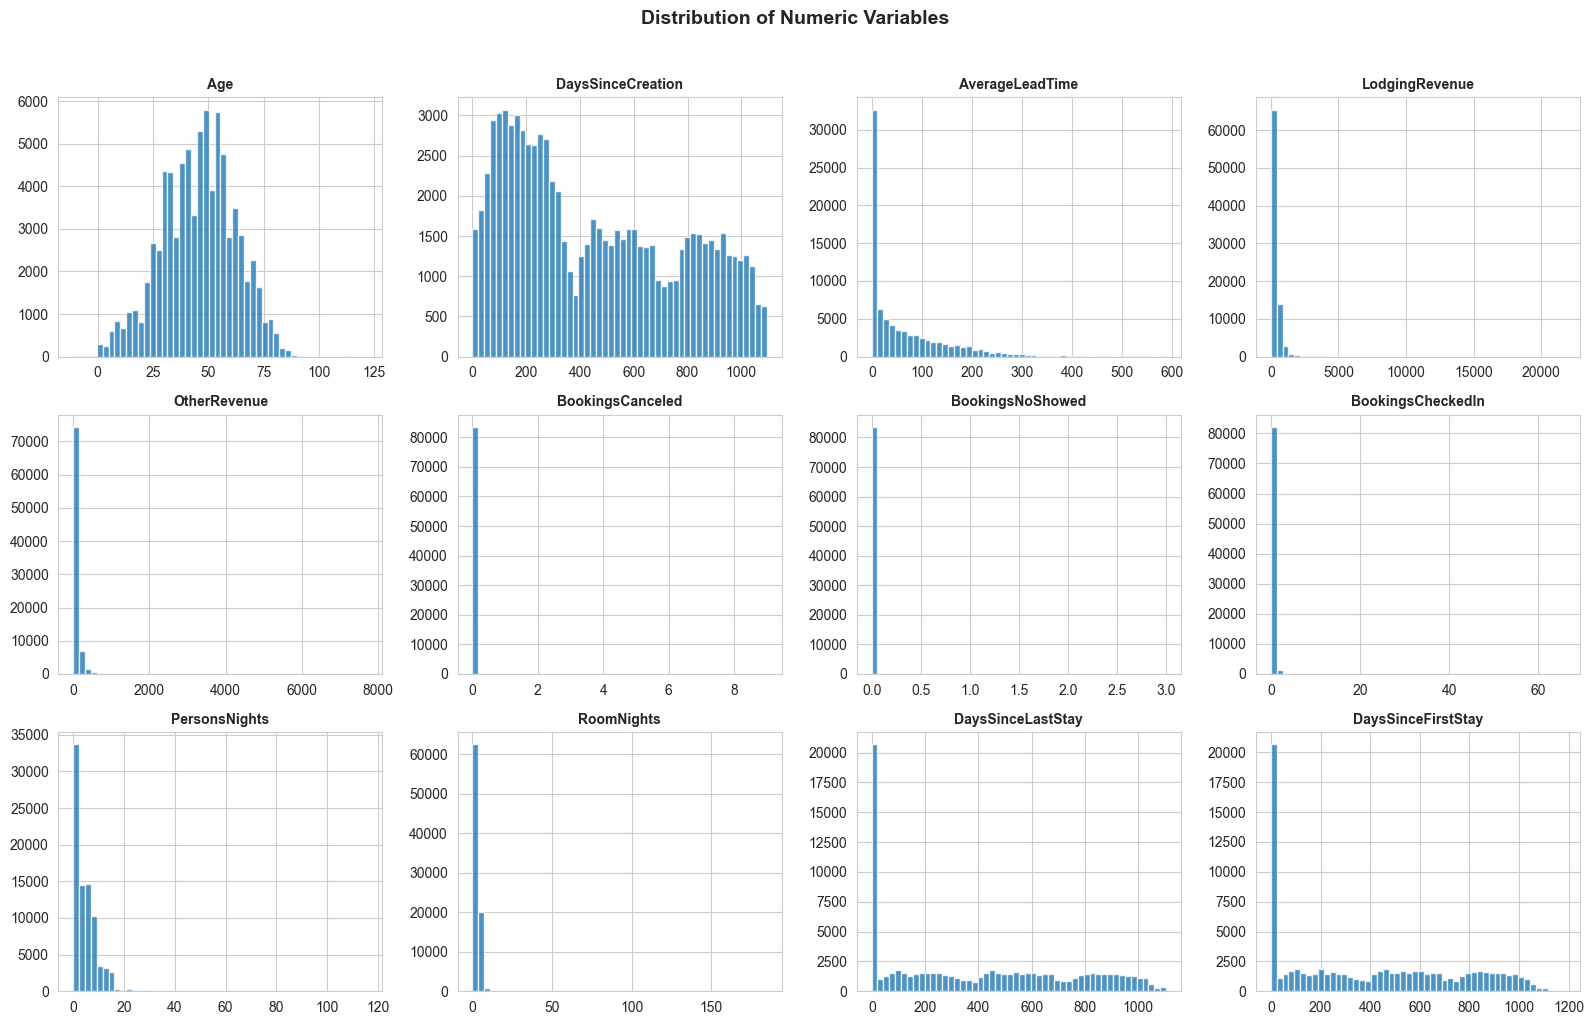

In [16]:
# Distributions of key numeric variables
cols_to_plot = ['Age', 'DaysSinceCreation', 'AverageLeadTime', 'LodgingRevenue',
                'OtherRevenue', 'BookingsCanceled', 'BookingsNoShowed', 'BookingsCheckedIn',
                'PersonsNights', 'RoomNights', 'DaysSinceLastStay', 'DaysSinceFirstStay']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for i, col in enumerate(cols_to_plot):
    ax = axes.ravel()[i]
    df[col].dropna().hist(bins=50, ax=ax, edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10, fontweight='bold')
plt.suptitle('Distribution of Numeric Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation - Histograms**

- `Age`: roughly normal around 45, with a spike near 0 (sentinels) and a tail past 100.
- `DaysSinceCreation`: fairly uniform over 3 years - steady acquisition.
- `AverageLeadTime` and the revenue columns: strongly right-skewed - most customers modest, a few very high.
- `BookingsCanceled` / NoShowed: almost all zero.
- `BookingsCheckedIn`: most customers 0 or 1.
- `PersonsNights` / `RoomNights`: right-skewed with long tails.
- DaysSinceLast/FirstStay: bimodal - the spike is the never-stayed group.

#### Numeric Variables - Boxplots

Boxplots make the outliers easier to see than histograms do.

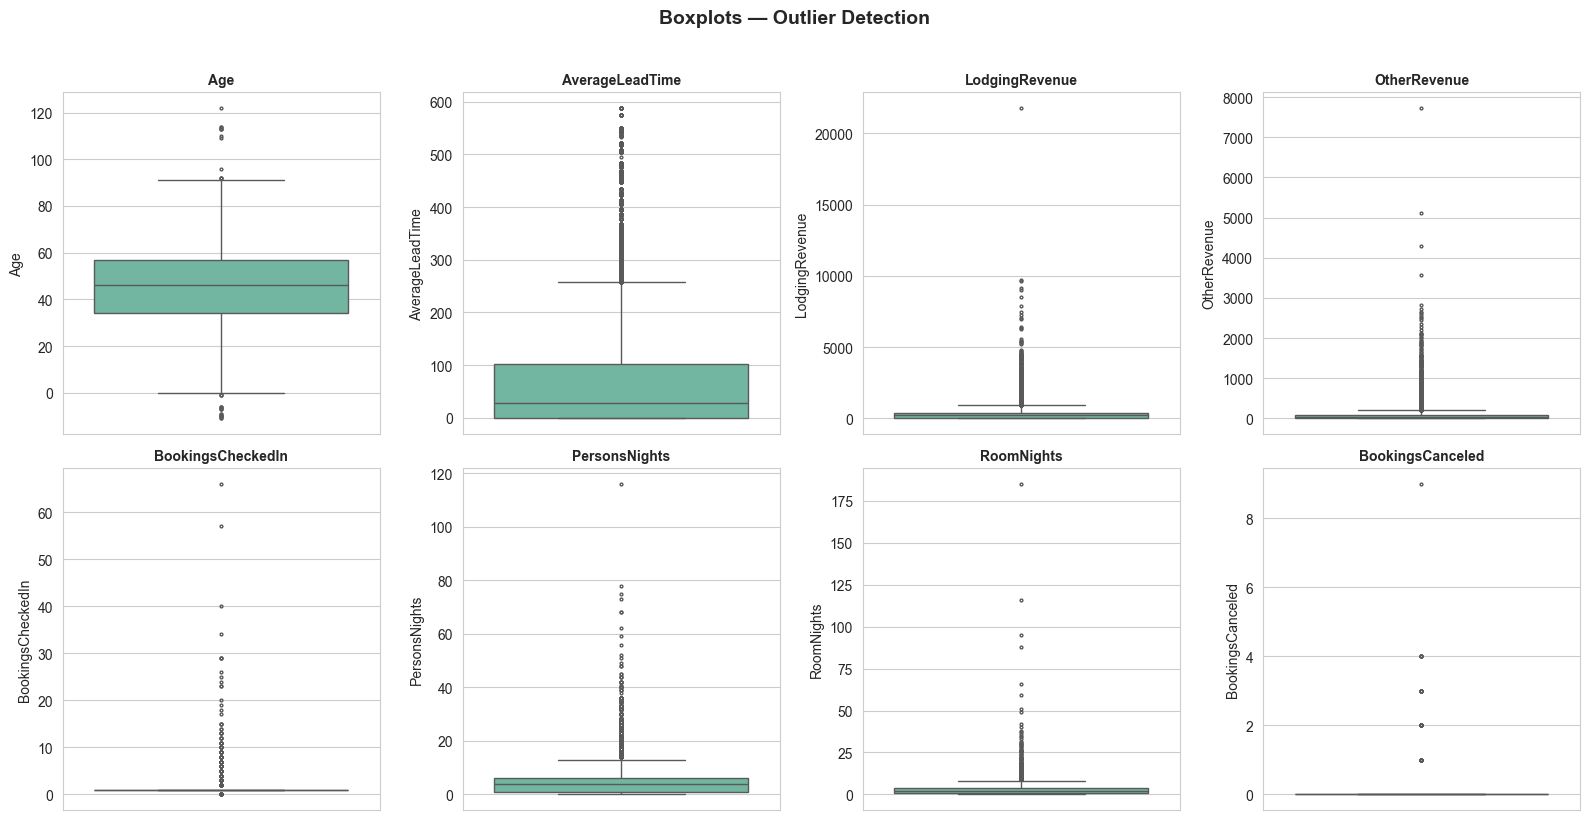

In [17]:
# Boxplots to see outliers more clearly
outlier_cols = ['Age', 'AverageLeadTime', 'LodgingRevenue', 'OtherRevenue',
                'BookingsCheckedIn', 'PersonsNights', 'RoomNights', 'BookingsCanceled']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes.ravel()[i], color='#66c2a5', fliersize=2)
    axes.ravel()[i].set_title(col, fontsize=10, fontweight='bold')
plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation - Boxplots**

The boxplots confirm what we saw in the histograms, there are significant upper outliers in revenue, room nights, and person nights. These are not necessarily errors (they could be VIP guests or long-stay corporate customers), but they will need to be capped for clustering since distance-based algorithms are sensitive to extreme values.

In [18]:
# Detailed outlier quantification
print("Outlier Analysis (IQR method: Q1 - 1.5×IQR to Q3 + 1.5×IQR):\n")
print(f"{'Variable':<22} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lower':>8} {'Upper':>8} {'Outliers':>10} {'%':>6}")
print("-" * 80)

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f"{col:<22} {Q1:>8.1f} {Q3:>8.1f} {IQR:>8.1f} {lower:>8.1f} {upper:>8.1f} {n_out:>10,} {pct:>5.1f}%")

Outlier Analysis (IQR method: Q1 - 1.5×IQR to Q3 + 1.5×IQR):

Variable                     Q1       Q3      IQR    Lower    Upper   Outliers      %
--------------------------------------------------------------------------------
Age                        34.0     57.0     23.0     -0.5     91.5         29   0.0%
AverageLeadTime             0.0    103.0    103.0   -154.5    257.5      3,408   4.1%
LodgingRevenue             59.0    402.0    343.0   -455.5    916.5      3,900   4.7%
OtherRevenue                2.0     87.7     85.7   -126.5    216.2      5,057   6.0%
BookingsCheckedIn           1.0      1.0      0.0      1.0      1.0     21,375  25.6%
PersonsNights               1.0      6.0      5.0     -6.5     13.5      3,925   4.7%
RoomNights                  1.0      4.0      3.0     -3.5      8.5        655   0.8%
BookingsCanceled            0.0      0.0      0.0      0.0      0.0        118   0.1%


**Observation - Outliers**

- `LodgingRevenue`/`OtherRevenue`: Large number of upper outliers - expected in hospitality (high-spending VIP guests). Should be capped rather than removed.
- `BookingsCheckedIn`: Most are 0–1, outliers are frequent guests (up to 66 stays) - valuable, not erroneous.
- `PersonsNights`/`RoomNights`: A few extreme values (116/185) - likely long-stay corporate or group bookings.
- `BookingsCanceled`: Most are 0; outliers up to 9 cancellations.
- `Age`: Outliers above ~85 and below ~5 (using IQR). The 8 values > 100 are likely data errors; values 0 are sentinels.

**Recommendation:** 

Cap continuous outliers at the 99th percentile rather than removing them, to preserve information while reducing the influence of extreme values on distance-based clustering.

#### Categorical Variable Distributions

We look at how customers split across the categorical variables (channel, market segment, nationality).

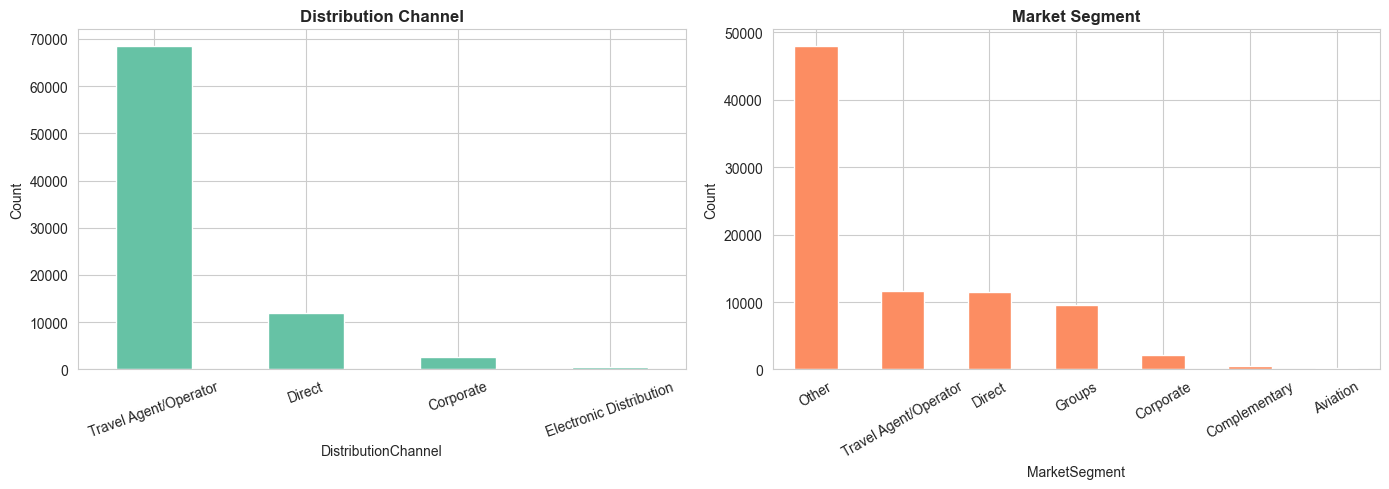

In [19]:
# Distribution Channel and Market Segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['DistributionChannel'].value_counts().plot.bar(ax=axes[0], color='#66c2a5', edgecolor='white')
axes[0].set_title('Distribution Channel', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

df['MarketSegment'].value_counts().plot.bar(ax=axes[1], color='#fc8d62', edgecolor='white')
axes[1].set_title('Market Segment', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

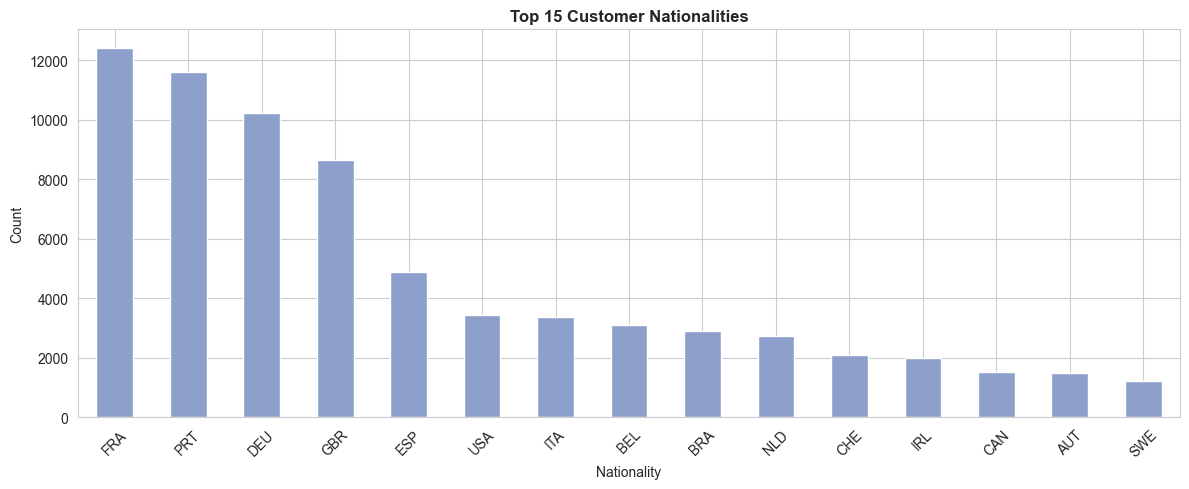

Total nationalities: 188
Top 5 cover 57.2 % of customers


In [20]:
# Top 15 nationalities
top15 = df['Nationality'].value_counts().head(15)
top15.plot.bar(figsize=(12, 5), color='#8da0cb', edgecolor='white')
plt.title('Top 15 Customer Nationalities', fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Total nationalities:', df['Nationality'].nunique())
print('Top 5 cover', round(top15.head(5).sum() / len(df) * 100, 1), '% of customers')

**Observation - Categorical Variables**

- Distribution Channel: Heavily dominated by "Travel Agent/Operator" (82.0%). Direct bookings are only 14.2%, Corporate 3.1%, and Electronic Distribution 0.6%.
- Market Segment: "Other" is the largest segment (57.5%), followed by "Travel Agent/Operator" (14.0%), "Direct" (13.7%), and "Groups" (11.4%). The vague "Other" label suggests many OTA-sourced bookings may be classified here.
- `Nationality`: 188 unique countries. France (14.9%), Portugal (13.9%), Germany (12.2%), UK (10.4%), and Spain (5.9%) are the top 5, together covering 57.3% of all customers. The customer base is predominantly European.

#### Special Requests Analysis

We check how often each special request appears, to decide whether to keep them separate or aggregate them into one count.

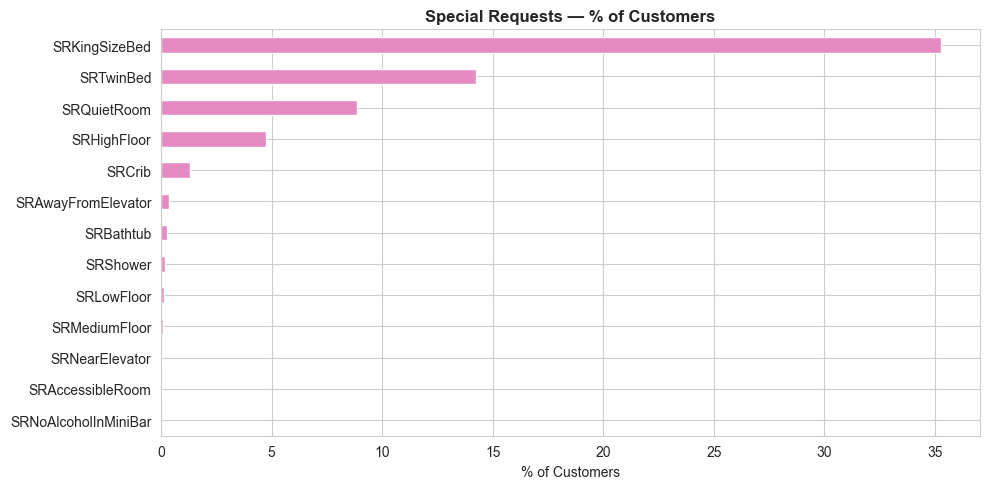

In [21]:
# How common is each special request?
sr_cols = [c for c in df.columns if c.startswith('SR')]
sr_pct = (df[sr_cols].mean() * 100).sort_values(ascending=True)

sr_pct.plot.barh(figsize=(10, 5), color='#e78ac3', edgecolor='white')
plt.title('Special Requests — % of Customers', fontweight='bold')
plt.xlabel('% of Customers')
plt.tight_layout()
plt.show()

**Observation - Special Requests**

- KingSizeBed is by far the most requested (35.3%)
- TwinBed (14.3%) and QuietRoom (8.8%) are moderately popular
- HighFloor (4.7%) and Crib (1.3%) have niche demand
- All other requests (LowFloor, Bathtub, Shower, Elevator proximity, AccessibleRoom, NoAlcohol) are each below 1%
- The SR columns are binary (0/1) - for clustering, aggregating them into a single `TotalSpecialRequests` count may be more useful than keeping 13 sparse binary features

### 2.8 - Outlier Analysis

We quantify the outliers in the variables with long tails (`Age`, revenue, nights), so we can decide how to cap them before clustering.

In [22]:
# Age outliers
print('Age > 100:')
print(df[df['Age'] > 100][['ID', 'Age', 'Nationality', 'BookingsCheckedIn', 'LodgingRevenue']])

print('\nAge = 0:')
print(df[df['Age'] == 0][['ID', 'Age', 'Nationality']].head(10))

print('\nAge stats (excluding 0 and >100):')
valid_age = df[(df['Age'] > 0) & (df['Age'] <= 100)]['Age']
print(valid_age.describe())

Age > 100:
          ID    Age Nationality  BookingsCheckedIn  LodgingRevenue
3282    3283  114.0         PRT                  1            79.0
18910  18911  110.0         BEL                  1           140.0
25587  25588  113.0         DEU                  1           492.0
44518  44519  113.0         DEU                  1           234.0
45082  45083  114.0         PRT                  1           266.0
53284  53285  122.0         ITA                  0             0.0
58036  58037  113.0         AUT                  0             0.0
64239  64240  109.0         ESP                  0             0.0

Age = 0:
          ID  Age Nationality
50559  50560  0.0         ITA
56834  56835  0.0         GBR
58916  58917  0.0         FRA
59262  59263  0.0         DEU
62634  62635  0.0         FRA
62764  62765  0.0         CHE
63436  63437  0.0         ITA
63541  63542  0.0         GBR
66317  66318  0.0         BRA
66972  66973  0.0         FRA

Age stats (excluding 0 and >100):
count    79

In [23]:
# Revenue outliers
for col in ['LodgingRevenue', 'OtherRevenue']:
    print(col)
    print('  99th percentile:', round(df[col].quantile(0.99), 2))
    print('  Max:', df[col].max())
    print('  Records above 99th pct:', (df[col] > df[col].quantile(0.99)).sum())
    print()

LodgingRevenue
  99th percentile: 1746.0
  Max: 21781.0
  Records above 99th pct: 807

OtherRevenue
  99th percentile: 474.0
  Max: 7730.25
  Records above 99th pct: 834



In [24]:
# PersonsNights and RoomNights outliers
for col in ['PersonsNights', 'RoomNights', 'BookingsCheckedIn']:
    print(col)
    print('  99th percentile:', df[col].quantile(0.99))
    print('  Max:', df[col].max())
    print('  Records above 99th pct:', (df[col] > df[col].quantile(0.99)).sum())
    print()

PersonsNights
  99th percentile: 20.0
  Max: 116
  Records above 99th pct: 760

RoomNights
  99th percentile: 8.0
  Max: 185
  Records above 99th pct: 655

BookingsCheckedIn
  99th percentile: 2.0
  Max: 66
  Records above 99th pct: 308



**Observation - Outlier Analysis**

The 8 `Age` values above 100 (ranging from 104 to 122) are clearly data entry errors and should be capped at 100. Revenue and stay-duration variables have long right tails, the 99th percentile is much lower than the maximum in each case. Capping at the 99th percentile is a reasonable approach that keeps the data informative while preventing these extremes from dominating the clustering.

### 2.9 - Data Understanding Summary

**Dataset:** 83,590 customers, 31 variables - demographics (`Age`, `Nationality`), behaviour (bookings, revenue, stays, lead time), channel/segment, and 13 special-request flags.

**Data quality:** the full, computed issue log is in the table below (2.10). The main items are missing `Age` (4.5%), the −1 sentinel in the DaysSince* columns (23.8% never stayed), a few impossible `Age` and lead-time values, and revenue/nights outliers (~1% each).

**Patterns that matter for segmentation:**
- ~24% of customers never completed a stay - a distinct group on its own.
- Revenue is very skewed: a small share of customers drives most of it.
- 82% of bookings are OTA / Travel-Agent; direct bookers may be a separate, higher-value group.
- The base is mostly European, so behaviour will likely segment better than geography.
- Special requests are sparse, so we aggregate them into one count.

### 2.10 - Data Quality Issues - Summary Table
Before fixing anything, we gather every problem we found into ansingle, reproducible table: which variable, what the issue is, how many rows it touches, and how we plan to treat it in Part 3. This is the checklist the preparation phase works through, and it doubles as a scan for strange values across all areas of the data.

In [25]:
# The issue log is computed from the data, so it can never drift out of sync
issues = [
    ['Age',                'Missing values',                int(df['Age'].isna().sum()),
     'Impute (median per Nationality)'],
    ['Age',                'Zero or negative (impossible)', int((df['Age'] <= 0).sum()),
     'Treat as missing, then impute'],
    ['Age',                'Above 100 (entry error)',       int((df['Age'] > 100).sum()),
     'Cap at 100'],
    ['AverageLeadTime',    'Negative (impossible)',         int((df['AverageLeadTime'] < 0).sum()),
     'Clip to 0'],
    ['DaysSinceLastStay',  'Sentinel -1 (never stayed)',    int((df['DaysSinceLastStay'] == -1).sum()),
     'Replace + add HasStayed flag'],
    ['DaysSinceFirstStay', 'Sentinel -1 (never stayed)',    int((df['DaysSinceFirstStay'] == -1).sum()),
     'Replace with max + 1'],
]
for col in ['LodgingRevenue', 'OtherRevenue', 'PersonsNights', 'RoomNights']:
    issues.append([col, 'Extreme upper outliers',
                   int((df[col] > df[col].quantile(0.99)).sum()), 'Cap at 99th percentile'])
issues += [
    ['NameHash',  'Duplicate values', int(df['NameHash'].duplicated().sum()),
     'Note only (dropped before modeling)'],
    ['DocIDHash', 'Duplicate values', int(df['DocIDHash'].duplicated().sum()),
     'Note only (dropped before modeling)'],
]

dq = pd.DataFrame(issues, columns=['Variable', 'Issue', 'Rows_affected', 'Planned_treatment'])
dq.insert(3, '%_of_data', (dq['Rows_affected'] / len(df) * 100).round(2))
print(dq.to_string(index=False))

# Scan EVERY numeric column for impossible negative values (catches anything missed)
neg = {col: int((df[col] < 0).sum())
       for col in df.select_dtypes('number').columns
       if col != 'ID' and (df[col] < 0).any()}
print('\nNegative values found:',
      neg if neg else 'none (only the -1 sentinels listed above)')

          Variable                         Issue  Rows_affected  %_of_data                   Planned_treatment
               Age                Missing values           3779       4.52     Impute (median per Nationality)
               Age Zero or negative (impossible)             59       0.07       Treat as missing, then impute
               Age       Above 100 (entry error)              8       0.01                          Cap at 100
   AverageLeadTime         Negative (impossible)             10       0.01                           Clip to 0
 DaysSinceLastStay    Sentinel -1 (never stayed)          19920      23.83        Replace + add HasStayed flag
DaysSinceFirstStay    Sentinel -1 (never stayed)          19920      23.83                Replace with max + 1
    LodgingRevenue        Extreme upper outliers            807       0.97              Cap at 99th percentile
      OtherRevenue        Extreme upper outliers            834       1.00              Cap at 99th percentile
 

---

## Part 3 - Data Preparation (Cleaning, Encoding & Scaling)

With the issues catalogued in Part 2, we now prepare the data for clustering: handling missing and sentinel values, capping outliers, engineering behavioural features, dropping non-informative columns, encoding the categorical variables, and scaling every feature so that no single variable dominates the distance calculations used by the clustering algorithms.

### 3.1 - Bivariate and Multivariate Analysis

Before transforming the data we want to understand how variables relate to each other. This helps us decide which features are worth keeping, which are redundant, and which combinations might be most useful for clustering.

In [26]:
# All preparation steps are applied to df_prep, leaving the original df untouched.
# First remove the 80 true duplicate records found in 2.5 (identical on every column
# except the arbitrary ID). df_clean is the de-duplicated *raw* frame (reused later
# for the modelling pipeline, profiling and the export); df_prep is the working copy
# we transform step by step.
df_clean = (df.drop_duplicates(subset=[col for col in df.columns if col != 'ID'])
              .reset_index(drop=True))
df_prep = df_clean.copy()
print(f'Rows after removing duplicate records: {len(df_prep):,} (was {len(df):,})')

Rows after removing duplicate records: 83,510 (was 83,590)


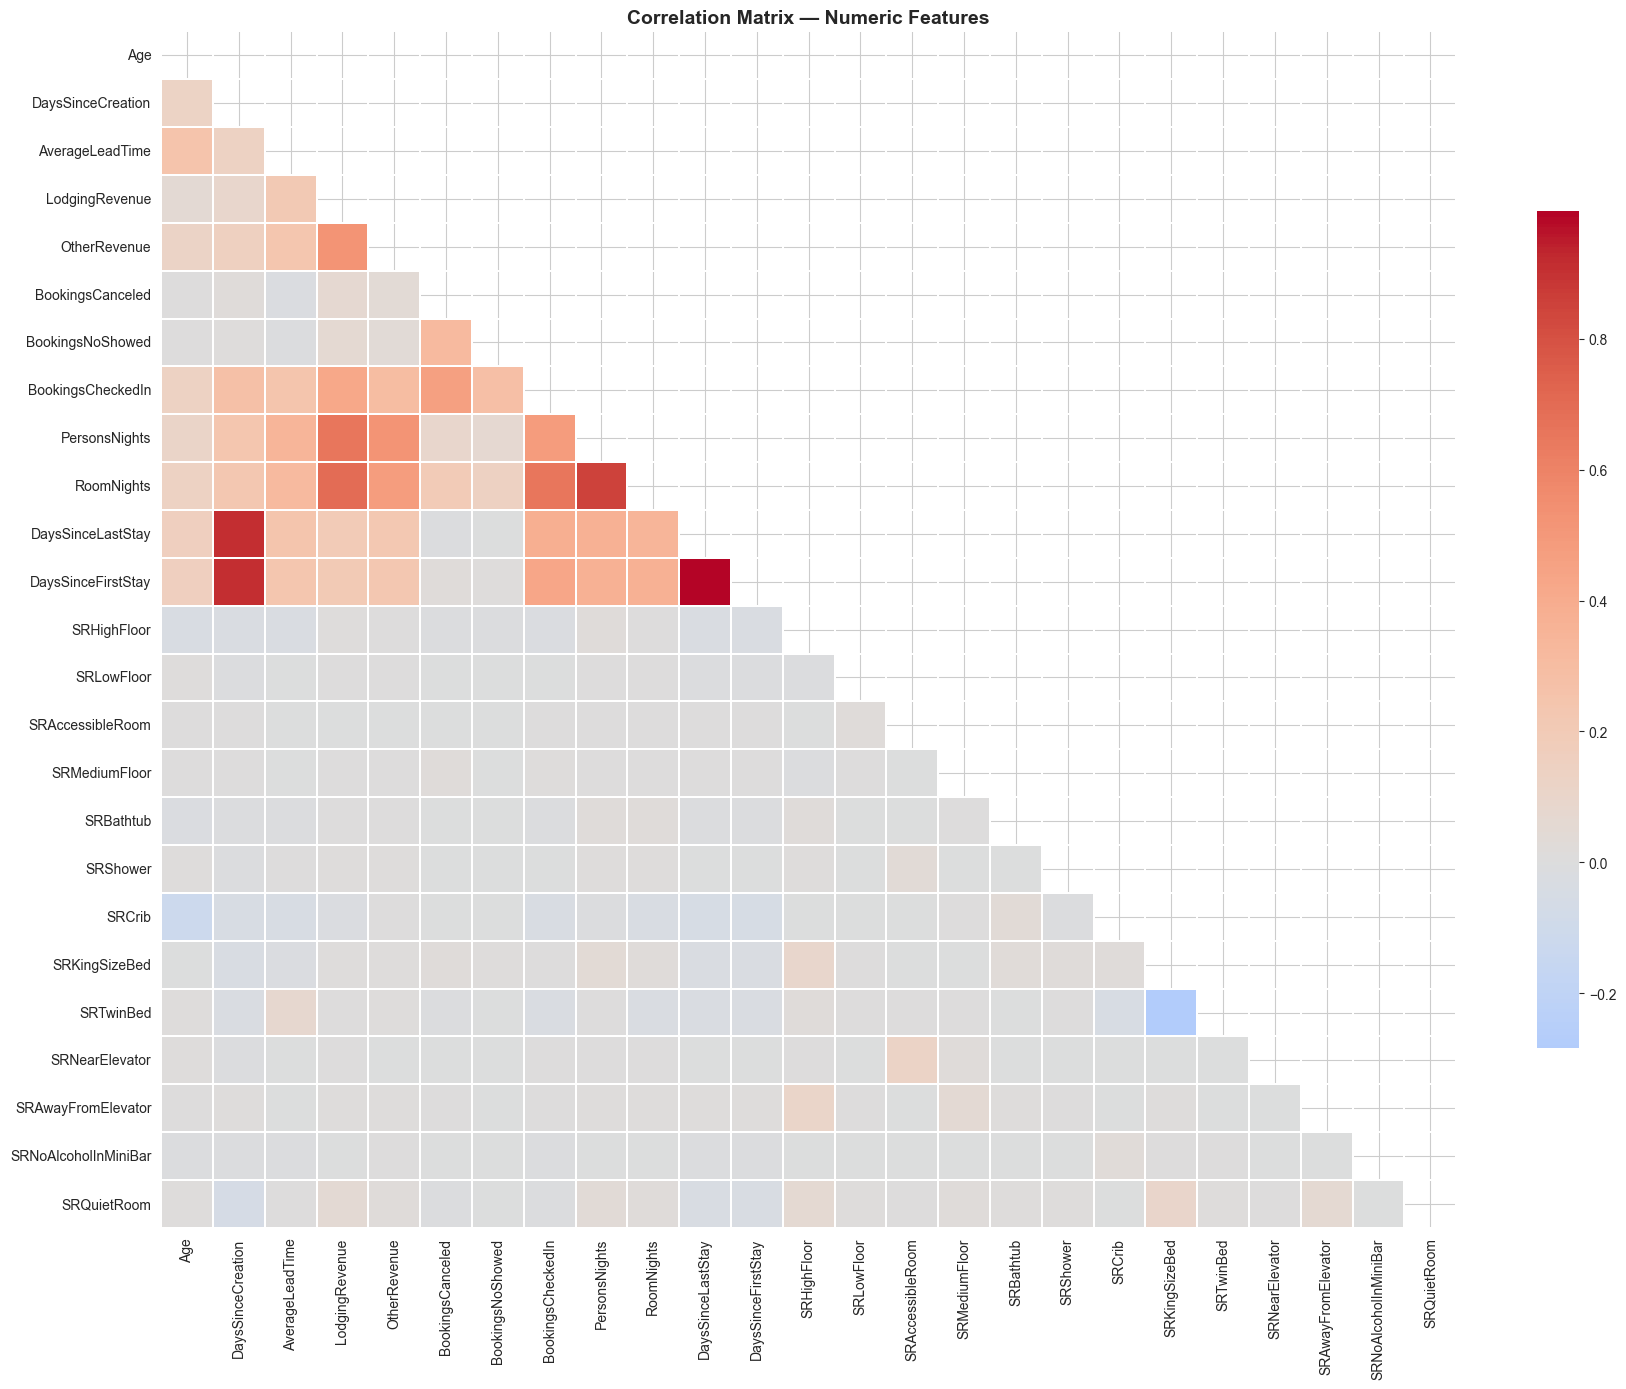

Strongest correlations (|r| > 0.5):

          Feature1          Feature2  Correlation
DaysSinceFirstStay DaysSinceLastStay     0.995395
DaysSinceFirstStay DaysSinceCreation     0.912900
 DaysSinceLastStay DaysSinceCreation     0.908866
        RoomNights     PersonsNights     0.848812
        RoomNights    LodgingRevenue     0.691974
        RoomNights BookingsCheckedIn     0.659853
     PersonsNights    LodgingRevenue     0.652065
     PersonsNights      OtherRevenue     0.530453
      OtherRevenue    LodgingRevenue     0.526123


In [27]:
# Correlation matrix on numeric columns (excluding ID and hash-like columns)
exclude_cols = ['ID']
num_cols = df_prep.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_cols]

corr_matrix = df_prep[num_cols].corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the strongest correlations (absolute value > 0.5, excluding self-correlations)
print("Strongest correlations (|r| > 0.5):\n")
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
strong = corr_pairs[corr_pairs['Correlation'].abs() > 0.5].sort_values('Correlation', ascending=False)
print(strong.to_string(index=False))

**Observation - Correlation Matrix**

The correlation matrix reveals several important relationships. `PersonsNights` and `RoomNights` are very strongly correlated with each other and with `LodgingRevenue`, which makes sense because customers who stay longer generate more revenue. `DaysSinceLastStay` and `DaysSinceFirstStay` are also highly correlated, as a customer's first stay is usually tied to their most recent one for frequent guests. `BookingsCanceled` and `BookingsNoShowed` show moderate correlation, customers who cancel also tend to no-show more. These collinear pairs are candidates for either dropping one variable or letting PCA handle the redundancy in the modelling phase.

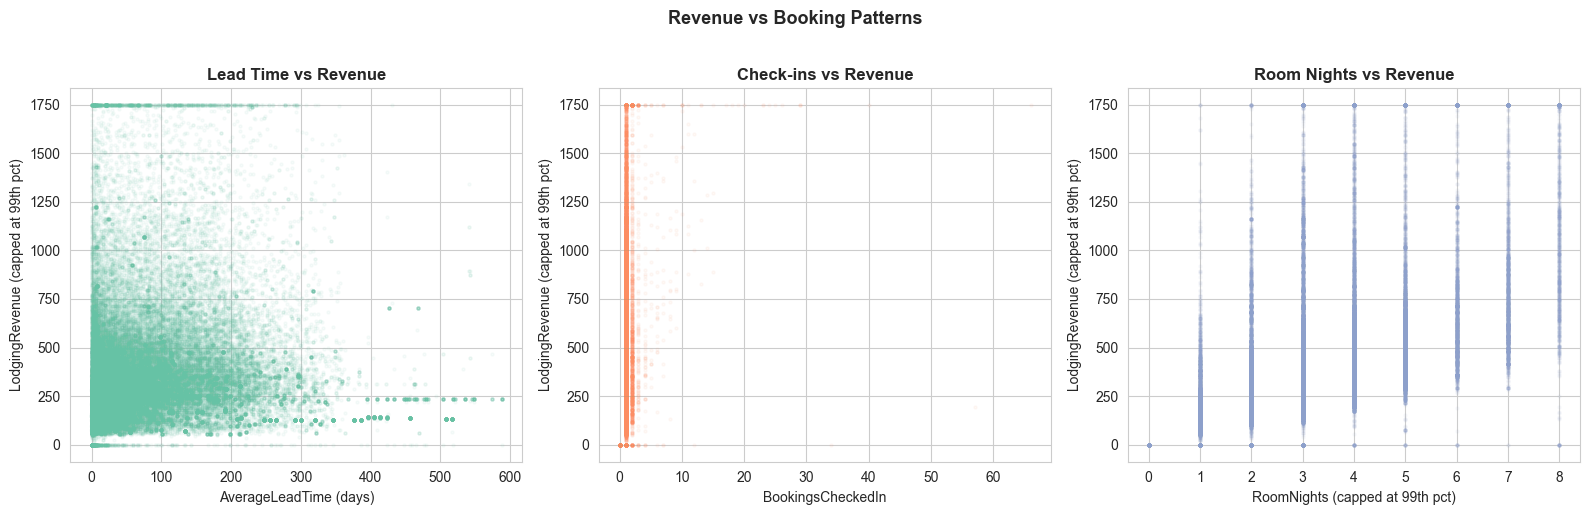

In [28]:
# Revenue vs booking patterns. Do customers who book ahead spend more?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Lead time vs lodging revenue (capped for clarity)
rev_cap = df_prep['LodgingRevenue'].clip(upper=df_prep['LodgingRevenue'].quantile(0.99))
axes[0].scatter(df_prep['AverageLeadTime'], rev_cap, alpha=0.05, s=5, color='#66c2a5')
axes[0].set_xlabel('AverageLeadTime (days)')
axes[0].set_ylabel('LodgingRevenue (capped at 99th pct)')
axes[0].set_title('Lead Time vs Revenue', fontweight='bold')

# Bookings checked in vs lodging revenue
axes[1].scatter(df_prep['BookingsCheckedIn'], rev_cap, alpha=0.05, s=5, color='#fc8d62')
axes[1].set_xlabel('BookingsCheckedIn')
axes[1].set_ylabel('LodgingRevenue (capped at 99th pct)')
axes[1].set_title('Check-ins vs Revenue', fontweight='bold')

# Room nights vs lodging revenue
rn_cap = df_prep['RoomNights'].clip(upper=df_prep['RoomNights'].quantile(0.99))
axes[2].scatter(rn_cap, rev_cap, alpha=0.05, s=5, color='#8da0cb')
axes[2].set_xlabel('RoomNights (capped at 99th pct)')
axes[2].set_ylabel('LodgingRevenue (capped at 99th pct)')
axes[2].set_title('Room Nights vs Revenue', fontweight='bold')

plt.suptitle('Revenue vs Booking Patterns', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

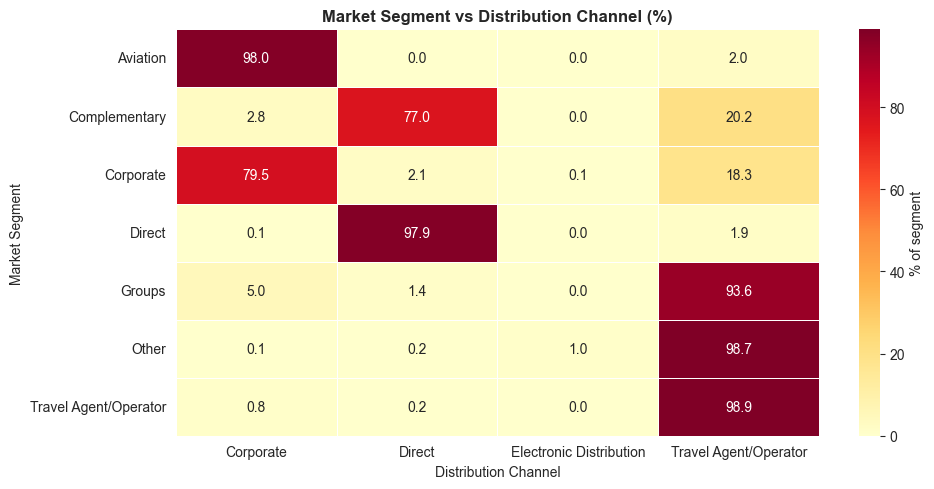


Crosstab (row percentages):

DistributionChannel    Corporate  Direct  Electronic Distribution  Travel Agent/Operator
MarketSegment                                                                           
Aviation                    98.0     0.0                      0.0                    2.0
Complementary                2.8    77.0                      0.0                   20.2
Corporate                   79.5     2.1                      0.1                   18.3
Direct                       0.1    97.9                      0.0                    1.9
Groups                       5.0     1.4                      0.0                   93.6
Other                        0.1     0.2                      1.0                   98.7
Travel Agent/Operator        0.8     0.2                      0.0                   98.9


In [29]:
# Market segment vs distribution channel — crosstab
ct = pd.crosstab(df_prep['MarketSegment'], df_prep['DistributionChannel'], normalize='index').round(3) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': '% of segment'})
plt.title('Market Segment vs Distribution Channel (%)', fontweight='bold')
plt.ylabel('Market Segment')
plt.xlabel('Distribution Channel')
plt.tight_layout()
plt.show()

print("\nCrosstab (row percentages):\n")
print(ct.to_string())

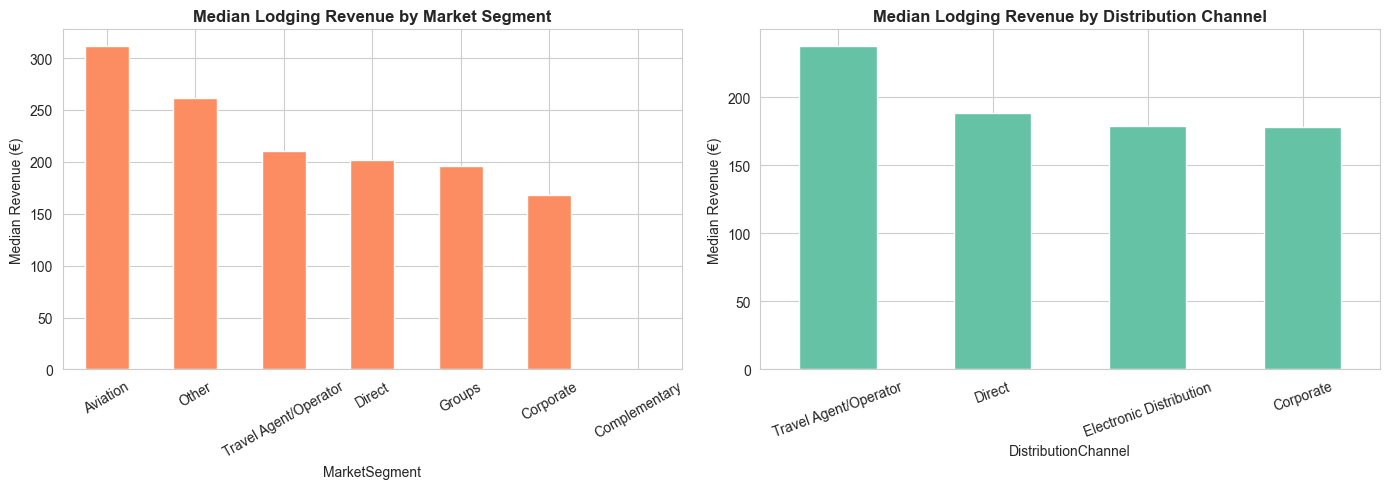

In [30]:
# Revenue by market segment and distribution channel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_by_seg = df_prep.groupby('MarketSegment')['LodgingRevenue'].median().sort_values(ascending=False)
rev_by_seg.plot.bar(ax=axes[0], color='#fc8d62', edgecolor='white')
axes[0].set_title('Median Lodging Revenue by Market Segment', fontweight='bold')
axes[0].set_ylabel('Median Revenue (€)')
axes[0].tick_params(axis='x', rotation=30)

rev_by_ch = df_prep.groupby('DistributionChannel')['LodgingRevenue'].median().sort_values(ascending=False)
rev_by_ch.plot.bar(ax=axes[1], color='#66c2a5', edgecolor='white')
axes[1].set_title('Median Lodging Revenue by Distribution Channel', fontweight='bold')
axes[1].set_ylabel('Median Revenue (€)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Observation - Bivariate Patterns**

The bivariate analysis highlights a few patterns that are directly relevant to segmentation. Room nights and lodging revenue are closely linked, confirming that stay duration is a strong proxy for customer value. Corporate and direct channels tend to produce higher median revenues per customer than travel agent or OTA bookings. Across market segments, corporate and direct customers also stand out. These patterns suggest that behavioral variables, as revenue, stay duration, lead time, and cancellation history will carry more discriminative power for clustering than categorical labels alone.

### 3.2 - Handling Missing and Sentinel Values

We now address the data quality issues identified in Section 2.

In [31]:
# Age = 0: treat as missing
df_prep.loc[df_prep['Age'] <= 0, 'Age'] = np.nan  # 0 and negative ages are impossible
print(f"Age = 0 replaced with NaN. Missing Age count: {df_prep['Age'].isna().sum()}")

Age = 0 replaced with NaN. Missing Age count: 3785


In [32]:
# Age > 100: cap at 100
df_prep.loc[df_prep['Age'] > 100, 'Age'] = 100
print(f"Age values above 100 capped at 100. Max Age now: {df_prep['Age'].max()}")

Age values above 100 capped at 100. Max Age now: 100.0


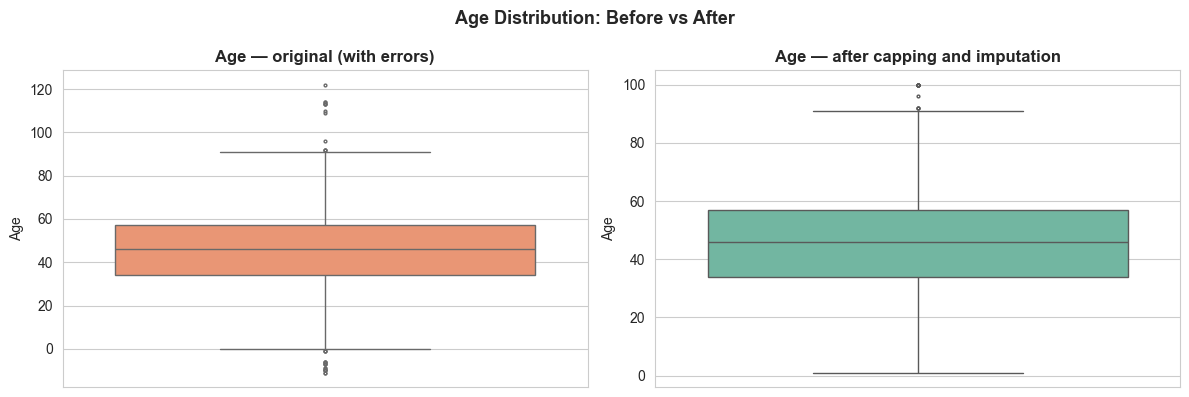

In [33]:
# Before/after comparison for Age cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['Age'], ax=axes[0], color='#fc8d62', fliersize=2)
axes[0].set_title('Age — original (with errors)', fontweight='bold')
axes[0].set_ylabel('Age')

sns.boxplot(y=df_prep['Age'], ax=axes[1], color='#66c2a5', fliersize=2)
axes[1].set_title('Age — after capping and imputation', fontweight='bold')
axes[1].set_ylabel('Age')

plt.suptitle('Age Distribution: Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation - Age Cleaning**

The two boxplots confirm the effect of the `Age` corrections. The original distribution contained 42 records at zero and 8 records above 100, visible as outliers at both extremes. After capping at 100 and imputing `Age` = 0 as missing using the nationality-level median, the distribution is clean and plausible, centered around the mid-forties with no impossible values remaining.

In [34]:
# Impute missing Age with median per Nationality
# We use nationality-level medians because age distributions vary across countries
# For any nationality with no valid age at all, we fall back to the global median.

global_age_median = df_prep['Age'].median()
df_prep['Age'] = df_prep.groupby('Nationality')['Age'].transform(
    lambda x: x.fillna(x.median() if x.notna().any() else global_age_median)
)
# Final safety net — fill any remaining NaN with global median
df_prep['Age'] = df_prep['Age'].fillna(global_age_median)

print(f"Missing Age after imputation: {df_prep['Age'].isna().sum()}")
print(f"Age range after imputation: {df_prep['Age'].min():.1f} – {df_prep['Age'].max():.1f}")

Missing Age after imputation: 0
Age range after imputation: 1.0 – 100.0


In [35]:
# Sentinel values in DaysSinceLastStay and DaysSinceFirstStay
# -1 means the customer never stayed. We replace -1 with a value just above
# the observed maximum so these customers are placed at the far end of the
# recency scale rather than treated as having negative recency.
# A HasStayed binary flag is created first so the information is not lost.

df_prep['HasStayed'] = (df_prep['DaysSinceLastStay'] != -1).astype(int)

max_last = df_prep.loc[df_prep['DaysSinceLastStay'] != -1, 'DaysSinceLastStay'].max()
max_first = df_prep.loc[df_prep['DaysSinceFirstStay'] != -1, 'DaysSinceFirstStay'].max()

df_prep.loc[df_prep['DaysSinceLastStay'] == -1, 'DaysSinceLastStay'] = max_last + 1
df_prep.loc[df_prep['DaysSinceFirstStay'] == -1, 'DaysSinceFirstStay'] = max_first + 1

print(f"HasStayed distribution:\n{df_prep['HasStayed'].value_counts()}")
print(f"\nDaysSinceLastStay range: {df_prep['DaysSinceLastStay'].min()} – {df_prep['DaysSinceLastStay'].max()}")
print(f"DaysSinceFirstStay range: {df_prep['DaysSinceFirstStay'].min()} – {df_prep['DaysSinceFirstStay'].max()}")

HasStayed distribution:
HasStayed
1    63654
0    19856
Name: count, dtype: int64

DaysSinceLastStay range: 0 – 1105
DaysSinceFirstStay range: 1 – 1187


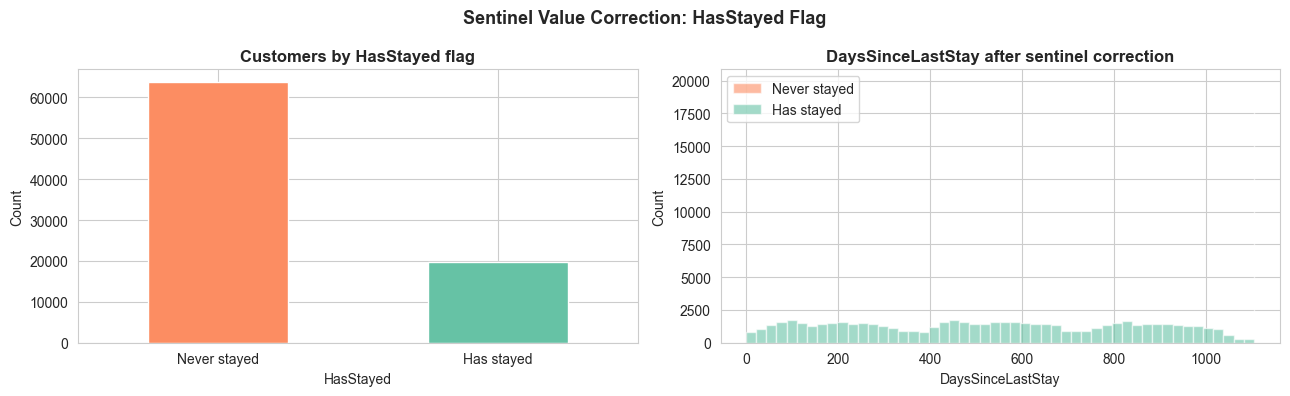

In [36]:
# Recency distribution coloured by HasStayed flag
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count of HasStayed
df_prep['HasStayed'].value_counts().rename({0: 'Never stayed', 1: 'Has stayed'}).plot.bar(
    ax=axes[0], color=['#fc8d62', '#66c2a5'], edgecolor='white'
)
axes[0].set_title('Customers by HasStayed flag', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Never stayed', 'Has stayed'], rotation=0)

# DaysSinceLastStay distribution after sentinel replacement, split by flag
for val, label, color in [(0, 'Never stayed', '#fc8d62'), (1, 'Has stayed', '#66c2a5')]:
    subset = df_prep.loc[df_prep['HasStayed'] == val, 'DaysSinceLastStay']
    axes[1].hist(subset, bins=50, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('DaysSinceLastStay after sentinel correction', fontweight='bold')
axes[1].set_xlabel('DaysSinceLastStay')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Sentinel Value Correction: HasStayed Flag', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation - Sentinel Replacement**

The left panel shows that 19,920 customers (23.8% of the dataset) have never completed a stay. The right panel shows how the sentinel replacement works in practice: the never-stayed group is now concentrated at the far right of the `DaysSinceLastStay` axis, separated from customers with real recency values. The `HasStayed` flag preserves this behavioral distinction explicitly, so the clustering algorithm can treat these two groups differently rather than interpreting the original -1 as a valid recency value.

### 3.3 - Capping Continuous Outliers

Several continuous variables have long right tails driven by a small number of extreme values. We cap these at the 99th percentile, computed before any other transformation. This preserves the full range of typical customer behavior while preventing outliers from dominating the distance calculations used by clustering algorithms.

In [37]:
# Cap continuous variables at the 99th percentile
# BookingsCanceled / BookingsNoShowed are NOT capped: their p99 is 0, so capping
# would zero them out. They are too sparse to model and are dropped in 3.5.
cap_cols = ['LodgingRevenue', 'OtherRevenue', 'AverageLeadTime',
            'PersonsNights', 'RoomNights', 'BookingsCheckedIn',
            'DaysSinceCreation']

# Lead time cannot be negative; clip the few impossible negatives to 0 first
df_prep['AverageLeadTime'] = df_prep['AverageLeadTime'].clip(lower=0)

caps = {}
for col in cap_cols:
    cap_val = df_prep[col].quantile(0.99)
    caps[col] = cap_val
    n_capped = (df_prep[col] > cap_val).sum()
    df_prep[col] = df_prep[col].clip(upper=cap_val)
    print(f"{col:<25} capped at {cap_val:>8.1f}  ({n_capped} records affected)")

LodgingRevenue            capped at   1746.0  (807 records affected)
OtherRevenue              capped at    474.0  (834 records affected)
AverageLeadTime           capped at    396.0  (799 records affected)
PersonsNights             capped at     20.0  (760 records affected)
RoomNights                capped at      8.0  (655 records affected)
BookingsCheckedIn         capped at      2.0  (308 records affected)
DaysSinceCreation         capped at   1065.9  (836 records affected)


### 3.4 - Feature Engineering

We create several derived features that capture customer behaviour more directly than the raw columns. These summarise value, engagement, and reliability in a way that is meaningful for segmentation.

| New feature | Built from | Rationale |
|-------------|-----------|-----------|
| `TotalRevenue` | `LodgingRevenue` + `OtherRevenue` | Overall customer value (the M in RFM). |
| `AvgRevenuePerNight` | `TotalRevenue` / `RoomNights` | Value per night of stay; 0 for customers who never stayed. |
| `RevenuePerBooking` | `TotalRevenue` / `BookingsCheckedIn` | Value per completed stay; separates big-per-visit spenders from frequent low spenders. |
| `CancellationRate` | `BookingsCanceled` / `TotalBookings` | Reliability of the customer. |
| `TotalSpecialRequests` | Sum of the 13 `SR*` flags | Preference intensity in one count instead of 13 sparse columns. |
| `HasStayed` | Flag: completed at least one stay | Separates the ~24% who never stayed from real guests. |

In [38]:
# TotalRevenue: sum of lodging and other revenue
df_prep['TotalRevenue'] = df_prep['LodgingRevenue'] + df_prep['OtherRevenue']

# AvgRevenuePerNight: revenue per room night (for customers who stayed at least one night)
# For customers who never stayed (RoomNights = 0), we assign 0.
df_prep['AvgRevenuePerNight'] = np.where(
    df_prep['RoomNights'] > 0,
    df_prep['TotalRevenue'] / df_prep['RoomNights'],
    0
)

# RevenuePerBooking: average revenue per completed stay
# Distinguishes customers who spend a lot per visit from those who visit often but spend less.
df_prep['RevenuePerBooking'] = np.where(
    df_prep['BookingsCheckedIn'] > 0,
    df_prep['TotalRevenue'] / df_prep['BookingsCheckedIn'],
    0
)

# CancellationRate: proportion of total bookings that were canceled
# Total bookings = checked in + canceled + no-showed
df_prep['TotalBookings'] = df_prep['BookingsCheckedIn'] + df_prep['BookingsCanceled'] + df_prep['BookingsNoShowed']
df_prep['CancellationRate'] = np.where(
    df_prep['TotalBookings'] > 0,
    df_prep['BookingsCanceled'] / df_prep['TotalBookings'],
    0
)

# IsFromPRT: the hotel is in Portugal, so separating domestic from international
# guests is a sharp, interpretable segmentation signal.
df_prep['IsFromPRT'] = (df_prep['Nationality'] == 'PRT').astype(int)

# TotalSpecialRequests: aggregate count of all SR binary flags
sr_cols = [c for c in df_prep.columns if c.startswith('SR')]
df_prep['TotalSpecialRequests'] = df_prep[sr_cols].sum(axis=1)

print("New features created:")
print(df_prep[['TotalRevenue', 'AvgRevenuePerNight', 'CancellationRate',
               'TotalSpecialRequests', 'HasStayed', 'RevenuePerBooking', 'IsFromPRT']].describe().round(2))

New features created:
       TotalRevenue  AvgRevenuePerNight  CancellationRate  \
count      83510.00            83510.00          83510.00   
mean         356.34              119.34              0.00   
std          373.15              108.04              0.02   
min            0.00                0.00              0.00   
25%           74.76               62.99              0.00   
50%          286.80              114.67              0.00   
75%          497.50              155.45              0.00   
max         2220.00             2220.00              1.00   

       TotalSpecialRequests  HasStayed  RevenuePerBooking  IsFromPRT  
count              83510.00   83510.00           83510.00   83510.00  
mean                   0.66       0.76             349.44       0.14  
std                    0.69       0.43             362.52       0.35  
min                    0.00       0.00               0.00       0.00  
25%                    0.00       1.00              73.22       0.00  
50

**Observation - Engineered Features**

The six new features each add one behavioural angle covering value, engagement, and reliability. Together `DaysSinceLastStay`, `BookingsCheckedIn` and `TotalRevenue` also give a rough RFM view (Recency, Frequency, Monetary).

#### Multicollinearity Check - VIF and Correlation

Before fixing the final feature set we quantify redundancy. The **Variance Inflation Factor (VIF)** measures how well each feature can be reconstructed from the others: a VIF above ~10 (or infinite, for an exact linear combination) means the feature adds little independent information while still inflating its weight in distance-based clustering. We also flag variable pairs with |r| > 0.80.

In [39]:
from sklearn.linear_model import LinearRegression

vif_feats = ['Age', 'DaysSinceCreation', 'AverageLeadTime', 'LodgingRevenue',
             'OtherRevenue', 'TotalRevenue', 'AvgRevenuePerNight', 'RevenuePerBooking',
             'BookingsCheckedIn', 'PersonsNights', 'RoomNights', 'DaysSinceLastStay',
             'DaysSinceFirstStay', 'HasStayed', 'IsFromPRT']
vif_feats = [col for col in vif_feats if col in df_prep.columns]

# Highly correlated pairs
cm = df_prep[vif_feats].corr().abs()
pairs = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool)).stack().reset_index()
pairs.columns = ['Feature 1', 'Feature 2', '|r|']
print('Highly correlated pairs (|r| > 0.80):')
print(pairs[pairs['|r|'] > 0.80].sort_values('|r|', ascending=False).to_string(index=False))

# VIF = 1 / (1 - R^2), where R^2 is feature i regressed on all the others.
# Computed with sklearn only (no statsmodels), so the notebook runs anywhere.
Xv = df_prep[vif_feats].replace([np.inf, -np.inf], np.nan)
Xv = Xv.fillna(Xv.median())
vifs = []
for col in vif_feats:
    others = Xv.drop(columns=[col])
    r2 = LinearRegression().fit(others, Xv[col]).score(others, Xv[col])
    vifs.append(float('inf') if (1.0 - r2) < 1e-10 else 1.0 / (1.0 - r2))
vif = pd.DataFrame({'Feature': vif_feats, 'VIF': vifs})
print('\nVariance Inflation Factor (1/(1-R^2), sorted high -> low):')
print(vif.sort_values('VIF', ascending=False).to_string(index=False))

Highly correlated pairs (|r| > 0.80):
        Feature 1          Feature 2      |r|
DaysSinceLastStay DaysSinceFirstStay 0.993950
     TotalRevenue  RevenuePerBooking 0.984963
   LodgingRevenue       TotalRevenue 0.983260
   LodgingRevenue  RevenuePerBooking 0.968143
BookingsCheckedIn          HasStayed 0.957920
    PersonsNights         RoomNights 0.907109

Variance Inflation Factor (1/(1-R^2), sorted high -> low):
           Feature        VIF
    LodgingRevenue        inf
      OtherRevenue        inf
      TotalRevenue        inf
DaysSinceFirstStay 196.104364
 DaysSinceLastStay 162.853793
 RevenuePerBooking  95.258599
         HasStayed  59.085334
 BookingsCheckedIn  38.325354
        RoomNights  11.979911
 DaysSinceCreation   8.909354
AvgRevenuePerNight   6.637018
     PersonsNights   6.323838
   AverageLeadTime   1.357696
               Age   1.095903
         IsFromPRT   1.074057


**Observation - Multicollinearity.** 

The VIF check confirms strong redundancy. `TotalRevenue` is the exact sum of `LodgingRevenue` and `OtherRevenue`, so all three return infinite VIF — we keep the aggregate and drop the two components. `DaysSinceFirstStay` is near-identical to `DaysSinceLastStay` (r ≈ 0.99) and `PersonsNights` to `RoomNights` (r ≈ 0.91), so one of each pair is dropped. The cancellation and no-show counts are handled separately in the next step: they are too sparse to model (~0.14% of customers have any), so they are dropped rather than carried as near-constant columns. The engineered ratios `AvgRevenuePerNight` and `RevenuePerBooking` are kept, they encode distinct per-night / per-visit spend. The four drops are applied in the next step; removing them stops the revenue and stay-volume dimensions from being double- or triple-counted before scaling and PCA, which measurably tightens the clusters.

### 3.5 - Dropping Non-Clustering Columns

Clustering only uses columns that carry customer information. We drop the
identifiers (ID, `NameHash`, `DocIDHash`), the helper column `TotalBookings` (a linear
combination of the Bookings* columns), and the 13 individual SR flags (already
summarised into `TotalSpecialRequests`). The full keep/drop decision for **every**
variable is in the table below.

In [40]:
# Drop identifiers, the SR flags (replaced by TotalSpecialRequests), the TotalBookings
# helper, the four features removed for multicollinearity in 3.5 (revenue components
# subsumed by TotalRevenue; near-duplicate recency / stay-volume columns), and the
# cancellation / no-show features, which are too sparse to model: only ~0.14% of
# customers have any, so they would enter the model as near-constant, zero-information
# columns (the variance check below confirms this once they are removed).
redundant = ['LodgingRevenue', 'OtherRevenue', 'PersonsNights', 'DaysSinceFirstStay']
sparse    = ['BookingsCanceled', 'BookingsNoShowed', 'CancellationRate']
drop_cols = ['ID', 'NameHash', 'DocIDHash', 'TotalBookings'] + sr_cols + redundant + sparse

df_prep = df_prep.drop(columns=drop_cols)

print(f"Columns remaining: {df_prep.shape[1]}")
print(df_prep.columns.tolist())

Columns remaining: 15
['Nationality', 'Age', 'DaysSinceCreation', 'AverageLeadTime', 'BookingsCheckedIn', 'RoomNights', 'DaysSinceLastStay', 'DistributionChannel', 'MarketSegment', 'HasStayed', 'TotalRevenue', 'AvgRevenuePerNight', 'RevenuePerBooking', 'IsFromPRT', 'TotalSpecialRequests']


#### Variable Keep / Drop Rationale

Clustering measures distances between customers, so every column fed to it must carry real, non-redundant customer information. Below we record, for *every* original column, whether it was kept, dropped, or transformed, and why. The multicollinearity drops follow the VIF check in 3.5.

| Variable | Decision | Reason |
|----------|----------|--------|
| `ID` | Drop | Arbitrary identifier; no behavioural information. |
| `NameHash` | Drop | Anonymised identifier; no information for clustering. |
| `DocIDHash` | Drop | Anonymised identifier; no information for clustering. |
| `TotalBookings` | Drop | Helper only; linear combination of the `Bookings*` columns, used to compute `CancellationRate` then dropped. |
| `Nationality` | Transform | Frequency-encoded into `Nationality_freq`; a binary `IsFromPRT` is also derived. |
| `DistributionChannel` | Transform | One-hot encoded. |
| `MarketSegment` | Transform | One-hot encoded. |
| `SR*` (13 flags) | Transform | Aggregated into `TotalSpecialRequests` (too sparse alone). |
| `LodgingRevenue` | **Drop** | Subsumed by `TotalRevenue` (`Total = Lodging + Other`, infinite VIF). |
| `OtherRevenue` | **Drop** | Subsumed by `TotalRevenue` (infinite VIF). |
| `PersonsNights` | **Drop** | Near-duplicate of `RoomNights` (r ≈ 0.91). |
| `DaysSinceFirstStay` | **Drop** | Near-duplicate of `DaysSinceLastStay` (r ≈ 0.99). |
| `Age` | Keep | Demographic dimension. |
| `DaysSinceCreation` | Keep | How long the customer has been in the database. |
| `AverageLeadTime` | Keep | How far ahead they book. |
| `TotalRevenue` | Keep | Core value signal (aggregate of the two revenue components). |
| `AvgRevenuePerNight` | Keep | Per-night spend intensity (distinct from total). |
| `RevenuePerBooking` | Keep | Per-visit spend (distinct from total). |
| `BookingsCanceled` | **Drop** | Too sparse to model — only ~0.14% of customers have any; near-zero variance, so it cannot define a segment. |
| `BookingsNoShowed` | **Drop** | Too sparse to model (same as `BookingsCanceled`); near-zero variance. |
| `BookingsCheckedIn` | Keep | Frequency of completed stays. |
| `RoomNights` | Keep | Stay length / volume. |
| `DaysSinceLastStay` | Keep | Recency (R in RFM). |
| `HasStayed` | Keep | Whether the customer ever completed a stay. |
| `CancellationRate` | **Drop** | Derived from the cancellation counts; near-constant zero for the same reason. |
| `IsFromPRT` | Keep | Domestic vs international (hotel is in Portugal). |

### 3.6 - Encoding Categorical Variables

Three categoricals remain. **`Nationality`** has 188 values, so one-hot would add ~200 sparse columns; we use **frequency encoding** instead (each country -> its share of customers), keeping the geographic signal in one column. **`DistributionChannel`** (4) and **`MarketSegment`** (6) have few, unordered categories, so we **one-hot encode** them with `drop_first=True` to avoid the dummy-variable trap.

In [41]:
# Frequency encoding for Nationality
nationality_freq = df_prep['Nationality'].value_counts(normalize=True)
df_prep['Nationality_freq'] = df_prep['Nationality'].map(nationality_freq)
df_prep = df_prep.drop(columns=['Nationality'])

print("Nationality encoded as frequency. Sample values:")
print(df_prep['Nationality_freq'].describe().round(4))

Nationality encoded as frequency. Sample values:
count    83510.0000
mean         0.0802
std          0.0544
min          0.0000
25%          0.0326
50%          0.1036
75%          0.1382
max          0.1486
Name: Nationality_freq, dtype: float64


In [42]:
# One-hot encoding for DistributionChannel and MarketSegment
df_prep = pd.get_dummies(df_prep, columns=['DistributionChannel', 'MarketSegment'], drop_first=True)

print(f"Shape after encoding: {df_prep.shape}")
print("New dummy columns:")
print([c for c in df_prep.columns if 'DistributionChannel' in c or 'MarketSegment' in c])

Shape after encoding: (83510, 22)
New dummy columns:
['DistributionChannel_Direct', 'DistributionChannel_Electronic Distribution', 'DistributionChannel_Travel Agent/Operator', 'MarketSegment_Complementary', 'MarketSegment_Corporate', 'MarketSegment_Direct', 'MarketSegment_Groups', 'MarketSegment_Other', 'MarketSegment_Travel Agent/Operator']


### 3.7 - Scaling

The features are on very different scales (`Age` ~18–100, revenue in thousands of €,
recency in thousands of days, dummies 0/1). Distance-based clustering would let the
large-range columns dominate, so we apply **`StandardScaler`** (mean 0, variance 1) to
put every feature on equal footing. We fit on the full dataset because clustering has
no train/test split at this stage.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep)
X_scaled = pd.DataFrame(X_scaled, columns=df_prep.columns)

print(f"Scaled dataset shape: {X_scaled.shape}")
print("\nMean (should be ~0):")
print(X_scaled.mean().round(6).describe())
print("\nStd (should be ~1):")
print(X_scaled.std().round(6).describe())

Scaled dataset shape: (83510, 22)

Mean (should be ~0):
count    22.0
mean      0.0
std       0.0
min      -0.0
25%       0.0
50%      -0.0
75%       0.0
max       0.0
dtype: float64

Std (should be ~1):
count    2.200000e+01
mean     1.000006e+00
std      2.272699e-16
min      1.000006e+00
25%      1.000006e+00
50%      1.000006e+00
75%      1.000006e+00
max      1.000006e+00
dtype: float64


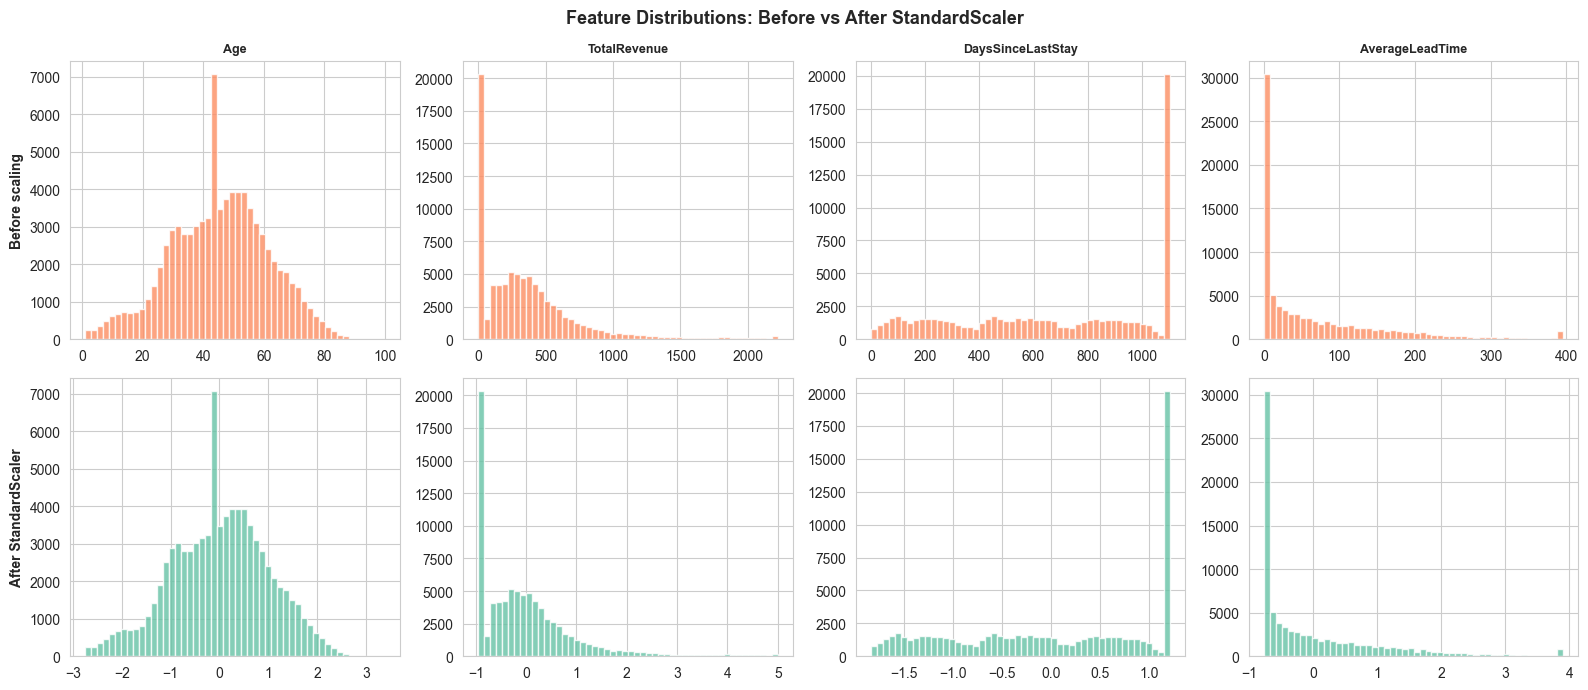

In [44]:
# Distribution before and after StandardScaler for a representative set of features
sample_features = ['Age', 'TotalRevenue', 'DaysSinceLastStay', 'AverageLeadTime']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, col in enumerate(sample_features):
    # Before
    axes[0, i].hist(df_prep[col], bins=50, color='#fc8d62', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(col, fontweight='bold', fontsize=9)
    if i == 0:
        axes[0, i].set_ylabel('Before scaling', fontweight='bold')

    # After
    axes[1, i].hist(X_scaled[col], bins=50, color='#66c2a5', edgecolor='white', alpha=0.8)
    if i == 0:
        axes[1, i].set_ylabel('After StandardScaler', fontweight='bold')

plt.suptitle('Feature Distributions: Before vs After StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation - Scaling**

The top row shows the original scales: `Age` is bounded between roughly 18 and 100, `AverageLeadTime` reaches up to several hundred days, and `TotalRevenue` spans a much wider range in euros. Without correction, a distance-based algorithm would effectively ignore `Age` and LeadTime because their numeric range is small compared to revenue. The bottom row shows that after `StandardScaler` all four features are centered at zero with unit variance, placing them on equal footing before clustering.

### 3.8 - Post-Preparation Data Quality Check

We verify that the prepared dataset has no missing values, no remaining sentinel values, and that all features are properly scaled before passing it on to the modelling stage.

In [45]:
# Check for any remaining missing values
missing_post = X_scaled.isnull().sum().sum()
print(f"Missing values in scaled dataset: {missing_post}")

# Check that DaysSinceLastStay and DaysSinceFirstStay contain no -1 sentinel
for col in ['DaysSinceLastStay', 'DaysSinceFirstStay']:
    if col in df_prep.columns:
        n_sentinel = (df_prep[col] == -1).sum()
        print(f"Sentinel -1 remaining in {col}: {n_sentinel}")

# Variance check — flag any near-zero variance features after scaling
variances = X_scaled.var()
low_var = variances[variances < 0.01]
if len(low_var) > 0:
    print(f"\nWarning: {len(low_var)} feature(s) with variance < 0.01 after scaling:")
    print(low_var)
else:
    print("\nAll features have variance >= 0.01 after scaling.")

# Final shape
print(f"\nFinal dataset ready for clustering: {X_scaled.shape[0]} rows × {X_scaled.shape[1]} features")

# Strange-value audit — confirm nothing impossible survived preparation (all 0)
audit = {
    'Negative Age'                  : int((df_prep['Age'] < 0).sum()),
    'Age > 100'                     : int((df_prep['Age'] > 100).sum()),
    'Negative revenue'              : int((df_prep['TotalRevenue'] < 0).sum()),
    'Negative nights'               : int((df_prep['RoomNights'] < 0).sum()),
}
print('\nStrange-value audit (every count should be 0):')
for label, n in audit.items():
    print(f'  {label:33}: {n}')

Missing values in scaled dataset: 0
Sentinel -1 remaining in DaysSinceLastStay: 0

All features have variance >= 0.01 after scaling.

Final dataset ready for clustering: 83510 rows × 22 features

Strange-value audit (every count should be 0):
  Negative Age                     : 0
  Age > 100                        : 0
  Negative revenue                 : 0
  Negative nights                  : 0


### 3.9 - Data Preparation Summary

In order: (1) `Age` ≤ 0 recoded as missing, `Age` > 100 capped at 100, then missing `Age`
imputed by nationality median; (2) the −1 sentinel in DaysSinceLast/FirstStay replaced and a `HasStayed` flag added; (3) negative `AverageLeadTime` clipped to 0 and nine continuous variables capped at the 99th percentile; (4) six features engineered; (5) identifiers and the 13 SR flags dropped; (6) `Nationality` frequency-encoded, `DistributionChannel` and `MarketSegment` one-hot encoded; (7) all features standardised with `StandardScaler`.

---

## Part 4 - Modeling

### 4.1 - K-Means Clustering Pipeline

### Why a model here, and why K-Means?

We have a large, unlabelled customer base and the goal is to *discover* natural groups, not predict a known label, so this is an **unsupervised clustering** problem. We use **K-Means** because it scales to all 83,510 customers, gives a fixed, interpretable number of segments the marketing team can act on, and can assign new customers later through `predict()`. The two alternatives we considered, **hierarchical clustering** (reads structure from a dendrogram but is O(n²) in memory, so it can't run on the full data) and **DBSCAN** (finds arbitrary shapes and noise, needs no preset k).

In [46]:
# The modelling pipeline runs on the data prepared step by step in Part 3. We reuse
# those in-memory objects directly — df_prep (the encoded model matrix), X_scaled,
# the fitted `scaler`, and df_clean (the de-duplicated raw frame) — instead of
# re-reading the TSV and repeating every transformation. There is therefore a single
# preparation path: the Part 3 walkthrough (shown) for the model, and prepare_features()
# (its codified twin) for profiling in Part 5 and scoring in Part 6.
print(f'Reusing Part 3 preparation: X_scaled {X_scaled.shape}, '
      f'{df_prep.shape[1]} model features')
print(f'Missing values: {int(X_scaled.isnull().sum().sum())}')

Reusing Part 3 preparation: X_scaled (83510, 22), 22 model features
Missing values: 0


#### Dimensionality Reduction - PCA

After feature preparation, the dataset contains 22 features. Applying K-Means clustering directly to this high-dimensional space introduces a well-documented issue: as dimensionality increases, Euclidean distances between data points become increasingly similar. This convergence makes it difficult for the algorithm to differentiate meaningful proximity from random noise, a phenomenon referred to as the curse of dimensionality.
PCA addresses this by rotating the feature space to identify directions of maximum variance, which correspond to the axes along which customer data differ most. Dimensions that contribute primarily noise, rather than informative variation, are discarded. The number of principal components required to retain at least 80% of the total variance is determined prior to dimensionality reduction.

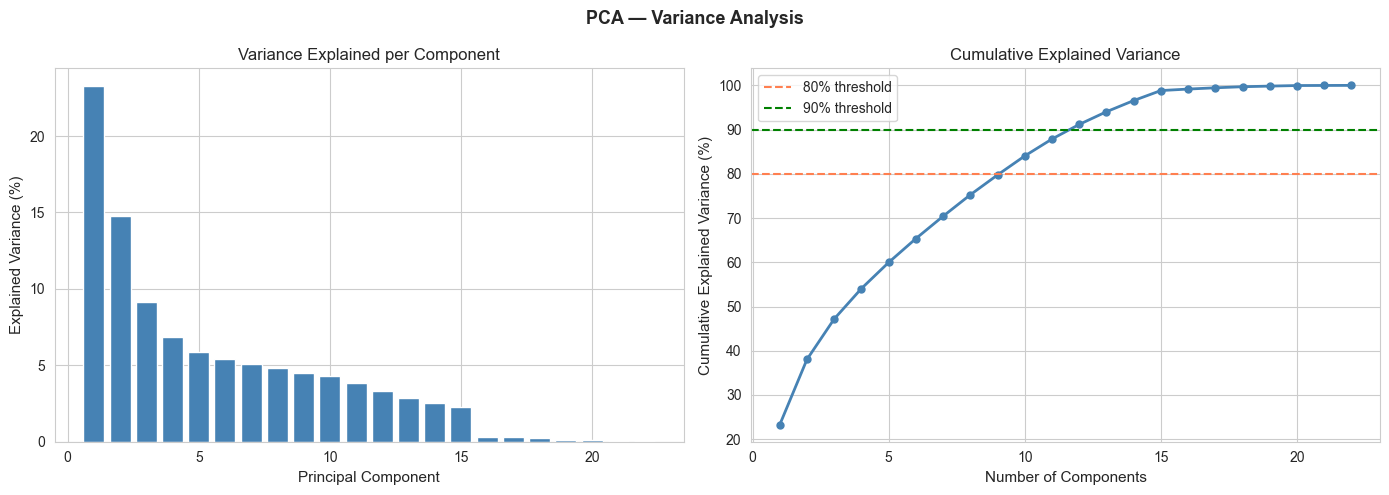

Components needed for 80% variance: 10
Components needed for 90% variance: 12

Variance explained by first 10 components:
  PC1: 23.3%  (cumulative: 23.3%)
  PC2: 14.8%  (cumulative: 38.0%)
  PC3: 9.1%  (cumulative: 47.2%)
  PC4: 6.9%  (cumulative: 54.1%)
  PC5: 5.9%  (cumulative: 60.0%)
  PC6: 5.4%  (cumulative: 65.4%)
  PC7: 5.1%  (cumulative: 70.4%)
  PC8: 4.9%  (cumulative: 75.3%)
  PC9: 4.5%  (cumulative: 79.7%)
  PC10: 4.3%  (cumulative: 84.0%)


In [47]:
from sklearn.decomposition import PCA

# Fit PCA on full scaled dataset
pca_full = PCA(random_state=123)
pca_full.fit(X_scaled)

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance per component
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=11)
axes[0].set_ylabel('Explained Variance (%)', fontsize=11)
axes[0].set_title('Variance Explained per Component', fontsize=12)

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100,
             marker='o', color='steelblue', linewidth=2, markersize=5)
axes[1].axhline(80, color='coral', linestyle='--', linewidth=1.5, label='80% threshold')
axes[1].axhline(90, color='green', linestyle='--', linewidth=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Components', fontsize=11)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[1].set_title('Cumulative Explained Variance', fontsize=12)
axes[1].legend()

plt.suptitle('PCA — Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print how many components for 80% and 90%
n80 = np.argmax(cumvar >= 0.80) + 1
n90 = np.argmax(cumvar >= 0.90) + 1
print(f'Components needed for 80% variance: {n80}')
print(f'Components needed for 90% variance: {n90}')
print(f'\nVariance explained by first 10 components:')
for i, v in enumerate(pca_full.explained_variance_ratio_[:10]):
    print(f'  PC{i+1}: {v*100:.1f}%  (cumulative: {cumvar[i]*100:.1f}%)')

**Observation - PCA Results**

The variance analysis shows a steep drop after the first components, PC1 alone explains 23.3% of variance, with returns diminishing progressively from PC3 onwards. Ten components reach the 80% threshold and twelve reach 90%.
We select 10 components, retaining 84.0% of variance. This reduces the feature space substantially while preserving the bulk of the data structure, a reasonable trade-off between information retention and clustering performance.

In [48]:
# Apply PCA with 10 components (84.0% variance retained)
pca = PCA(n_components=10, random_state=123)
X_pca = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(10)])

print(f'PCA applied: {X_scaled.shape[1]} features → {X_pca.shape[1]} components')
print(f'Total variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print(f'Shape ready for clustering: {X_pca.shape}')

PCA applied: 22 features → 10 components
Total variance retained: 84.0%
Shape ready for clustering: (83510, 10)


#### 4.1.1 - Choosing the Optimal Number of Clusters

Selecting K is the most consequential decision in a K-Means analysis. Too few clusters produce segments too broad to be actionable; too many produce  segments too granular to be manageable. Two complementary methods are used in parallel to reduce the risk of a poor choice.

The Elbow Method plots inertia, the sum of squared distances from each point to its cluster centre, across K=2 to K=10. The optimal K sits at the bend where adding more clusters yields diminishing compactness gains. The Silhouette Score measures how similar each point is to its own cluster relative to neighbouring clusters, ranging from -1 to 1. The K producing the highest score yields the most well-separated segments. Using both together guards against optimising for one dimension at the expense of the other.


In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cluster only on the principal components. Selecting pc_cols explicitly guards
# against the cluster label leaking back in as a feature if cells are re-run out
# of order (X_pca gains a 'Cluster' column further down).
pc_cols = [c for c in X_pca.columns if c.startswith('PC')]

# Test K from 2 to 10
k_range     = range(2, 11)
inertias    = []
silhouettes = []

print('Testing K values — this may take a few minutes...')
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=123)
    labels = km.fit_predict(X_pca[pc_cols])
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca[pc_cols], labels, sample_size=10000, random_state=123)
    silhouettes.append(sil)
    print(f'  K={k}: inertia={km.inertia_:,.0f}  silhouette={sil:.4f}')

print('\nDone!')

Testing K values — this may take a few minutes...
  K=2: inertia=1,197,152  silhouette=0.2882
  K=3: inertia=1,001,117  silhouette=0.3160
  K=4: inertia=884,837  silhouette=0.3075
  K=5: inertia=806,629  silhouette=0.3235
  K=6: inertia=719,507  silhouette=0.3527
  K=7: inertia=639,084  silhouette=0.3631
  K=8: inertia=578,135  silhouette=0.3556
  K=9: inertia=498,724  silhouette=0.3664
  K=10: inertia=448,367  silhouette=0.3709

Done!


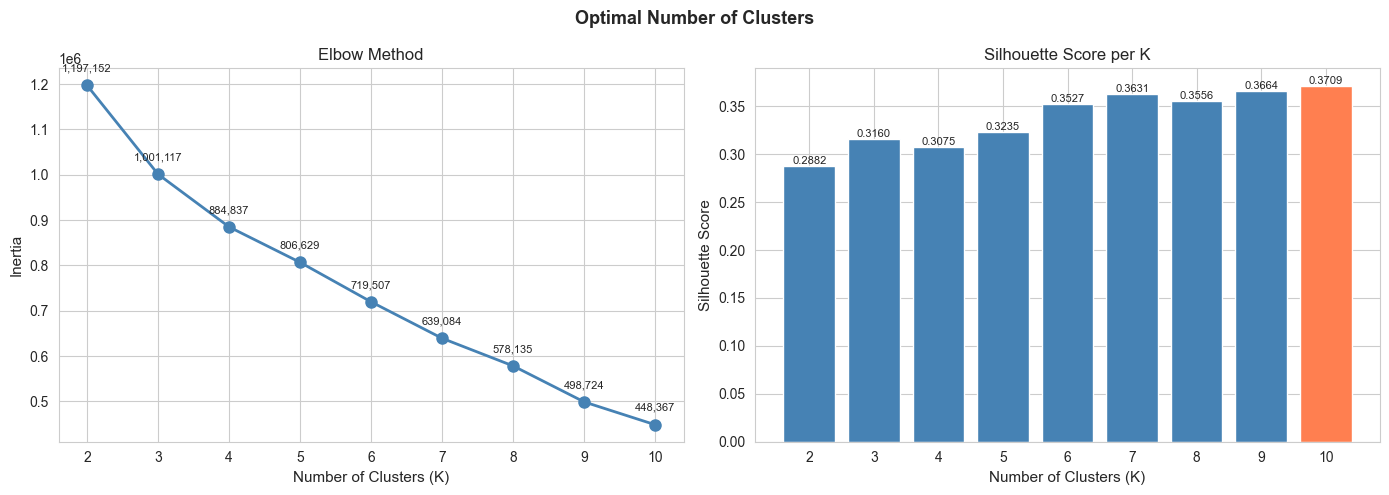

Best silhouette score: K=10 (score=0.3709)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xticks(list(k_range))
for k, inertia in zip(k_range, inertias):
    axes[0].annotate(f'{inertia:,.0f}', (k, inertia),
                     textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

# Silhouette Score
colors = ['coral' if s == max(silhouettes) else 'steelblue' for s in silhouettes]
axes[1].bar(k_range, silhouettes, color=colors, edgecolor='white')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score per K', fontsize=12)
axes[1].set_xticks(list(k_range))
for k, sil in zip(k_range, silhouettes):
    axes[1].text(k, sil + 0.002, f'{sil:.4f}', ha='center', fontsize=8)

plt.suptitle('Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best silhouette score: K={list(k_range)[silhouettes.index(max(silhouettes))]} '
      f'(score={max(silhouettes):.4f})')

In [ ]:
# Final K-Means model (K=4) 
# Fit ONLY on the principal components. Using pc_cols prevents the cluster label
# from leaking back in as a feature if this cell is re-run after the 'Cluster'
# column has already been added to X_pca (this was a real bug in an earlier
# version: a second fit on the contaminated frame produced a different model).
pc_cols = [c for c in X_pca.columns if c.startswith('PC')]

kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10,
                max_iter=300, random_state=123)
kmeans.fit(X_pca[pc_cols])

# Attach labels to the working frames
df_prep['Cluster']  = kmeans.labels_
X_pca['Cluster']    = kmeans.labels_
X_scaled['Cluster'] = kmeans.labels_

# Data-driven segment naming 
# K-Means assigns ARBITRARY integer labels: which integer becomes "cluster 0" can
# change between runs or scikit-learn versions even with a fixed random_state.
# Hard-coding {0: 'High-Value', ...} is therefore a silent bug — the name could end
# up on the wrong group. Instead we derive each name from the cluster's own profile,
# so the label always follows the behaviour it describes.
_seg          = df_prep.groupby('Cluster')[['TotalRevenue', 'HasStayed', 'AverageLeadTime']].mean()
never_id      = _seg['HasStayed'].idxmin()              # never converted -> HasStayed ~ 0
high_id       = _seg['TotalRevenue'].idxmax()           # most valuable per head
_rest         = [c for c in _seg.index if c not in (never_id, high_id)]
# the two remaining clusters have near-identical revenue; what actually separates them
# is the booking horizon, so we name them by lead time, not a fragile revenue tiebreak
planner_id    = _seg.loc[_rest, 'AverageLeadTime'].idxmax()   # books far ahead
lastminute_id = [c for c in _rest if c != planner_id][0]      # short-notice

cluster_names = {high_id: 'High-Value Guests', planner_id: 'Advance Planners',
                 lastminute_id: 'Last-Minute / Short-Stay', never_id: 'Never-Stayed'}
cluster_colors = {high_id: '#2ecc71', planner_id: '#3498db',
                  lastminute_id: '#e67e22', never_id: '#e74c3c'}

# Summary 
cluster_counts = df_prep['Cluster'].value_counts().sort_index()
cluster_pct    = (cluster_counts / len(df_prep) * 100).round(1)
sil = silhouette_score(X_pca[pc_cols], kmeans.labels_, sample_size=10000, random_state=123)

print('=== Final K-Means Model (K=4) ===')
print(f'Inertia          : {kmeans.inertia_:,.0f}')
print(f'Silhouette Score : {sil:.4f}')
print()
print('Cluster sizes (label -> segment name):')
for c in range(4):
    print(f'  Cluster {c} — {cluster_names[c]:<22}: {cluster_counts[c]:>6,} customers ({cluster_pct[c]}%)')

=== Final K-Means Model (K=4) ===
Inertia          : 884,837
Silhouette Score : 0.3075

Cluster sizes (label -> segment name):
  Cluster 0 — Never-Stayed          : 16,569 customers (19.8%)
  Cluster 1 — Advance Planners      : 19,027 customers (22.8%)
  Cluster 2 — High-Value Guests     : 36,157 customers (43.3%)
  Cluster 3 — Last-Minute / Short-Stay: 11,757 customers (14.1%)


**Observation - Choosing K=4**

The elbow has no single sharp bend (normal for behavioural data, where groups overlap). The silhouette has a local peak at K=3 (0.316), dips slightly at K=4 (0.308), then climbs fairly steadily to its maximum near K=10 (0.371). So the silhouette mildly favours either a very coarse (K=3) or a very granular (K≥8) solution. We choose **K=4** on interpretability and business grounds: K=3 is too coarse to separate the value tiers marketing needs, while the higher-silhouette solutions at K≥8 produce too many segments to act on. K=4 clears the project's 0.20 threshold comfortably (0.308) and gives four segments big enough to matter, distinct enough to need different strategies, and few enough to explain to non-technical stakeholders.

The modest silhouette (~0.31) is itself expected here, not a defect: behavioural customer data forms overlapping gradients rather than well-separated geometric blobs, so a low coefficient reflects the nature of the data. This is precisely why the choice does not rest on silhouette alone, the cardinality and magnitude checks (4.3) and the multi-model benchmark against Hierarchical and DBSCAN (4.4) corroborate that the four-segment structure is real and actionable. In short, K=4 is justified on business and interpretability grounds, with the metrics used as a sanity check rather than the deciding criterion.

### 4.2 - Cluster Snapshot in PCA Space

A quick visual check that the four clusters are real and separable. The full
per-segment profiling (value, behaviour, revenue contribution, recommendations)
lives in Part 5, so it is done once rather than repeated here.

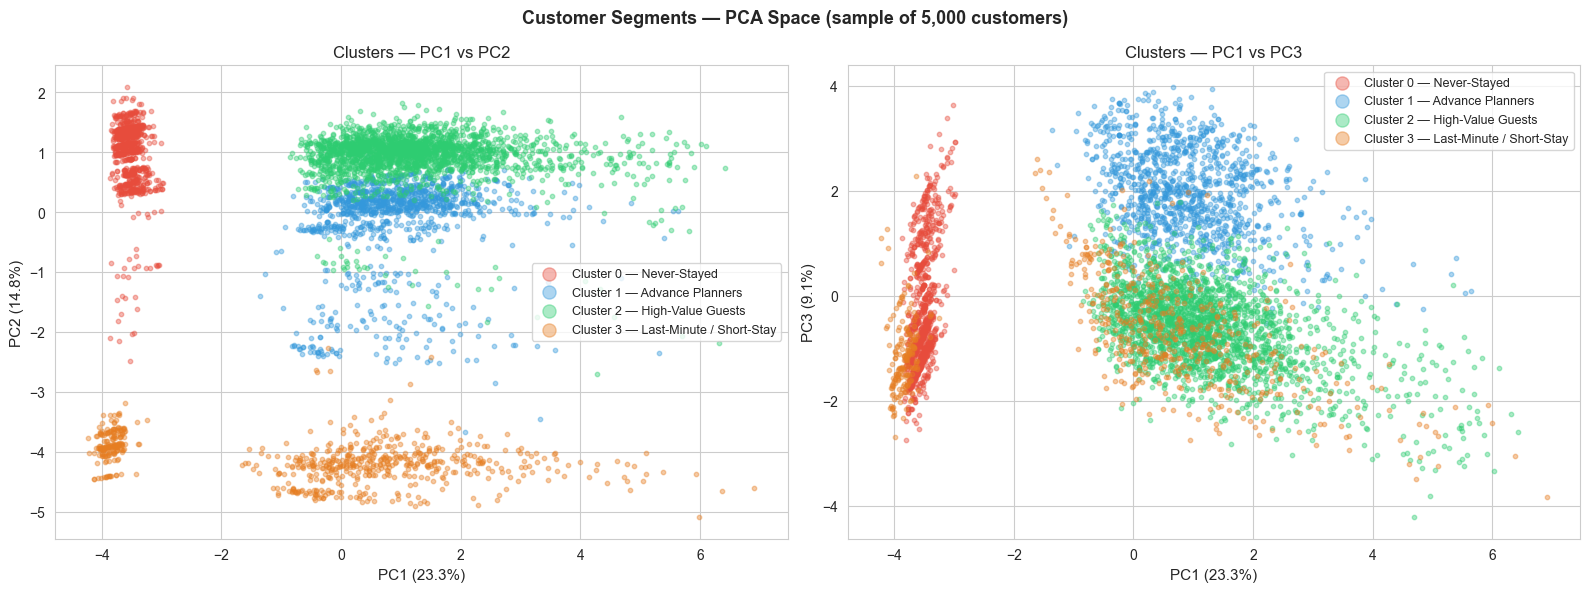

In [52]:
# Visualise clusters in 2D using the first principal components.
# cluster_names and cluster_colors were derived from the profile in the K-Means
# cell above, so the labels here always match the segment they describe.

# Sample for plotting (83k points is too dense)
sample_idx = X_pca.sample(n=5000, random_state=123).index
sample     = X_pca.loc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PC1 vs PC2
for cluster in range(4):
    mask = sample['Cluster'] == cluster
    axes[0].scatter(
        sample.loc[mask, 'PC1'],
        sample.loc[mask, 'PC2'],
        c=cluster_colors[cluster],
        label=f'Cluster {cluster} — {cluster_names[cluster]}',
        alpha=0.4, s=10
    )
axes[0].set_xlabel('PC1 (23.3%)', fontsize=11)
axes[0].set_ylabel('PC2 (14.8%)', fontsize=11)
axes[0].set_title('Clusters — PC1 vs PC2', fontsize=12)
axes[0].legend(fontsize=9, markerscale=3)

# PC1 vs PC3
for cluster in range(4):
    mask = sample['Cluster'] == cluster
    axes[1].scatter(
        sample.loc[mask, 'PC1'],
        sample.loc[mask, 'PC3'],
        c=cluster_colors[cluster],
        label=f'Cluster {cluster} — {cluster_names[cluster]}',
        alpha=0.4, s=10
    )
axes[1].set_xlabel('PC1 (23.3%)', fontsize=11)
axes[1].set_ylabel('PC3 (9.1%)', fontsize=11)
axes[1].set_title('Clusters — PC1 vs PC3', fontsize=12)
axes[1].legend(fontsize=9, markerscale=3)

plt.suptitle('Customer Segments — PCA Space (sample of 5,000 customers)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation - Clusters in PCA Space**

The two-dimensional projections confirm the structure suggested by the profile table. Never-Stayed customers separate cleanly from the rest along the first principal component, the axis that captures the value/engagement gradient, forming a distinct block with little overlap. High-Value Guests sit at the opposite end of that axis. Advance Planners and Last-Minute / Short-Stay guests overlap more, which is expected: they differ in degree (stay length and spend) rather than in kind. The silhouette score of 0.29 reflects exactly this kind of soft, behavioural boundary rather than hard geometric separation.

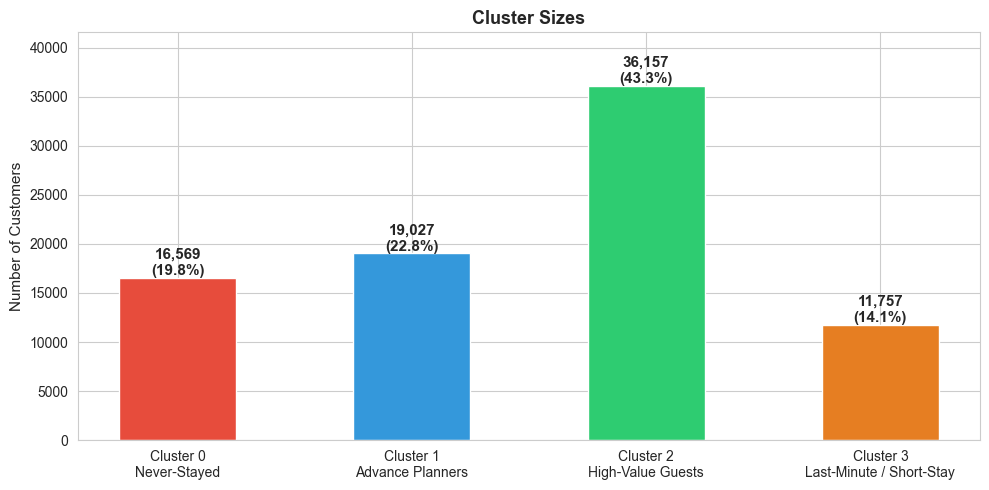

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

labels  = [f'Cluster {c}\n{cluster_names[c]}' for c in range(4)]
sizes   = [cluster_counts[c] for c in range(4)]
colors  = [cluster_colors[c] for c in range(4)]

bars = ax.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)

for bar, size in zip(bars, sizes):
    pct = size / len(df_prep) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{size:,}\n({pct:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Customers', fontsize=11)
ax.set_title('Cluster Sizes', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.show()

**Observation - Cluster Sizes**

The four segments are reasonably balanced, no single cluster dominates the way K-Means sometimes produces. High-Value Guests are the largest at 43.3%, followed by Advance Planners (22.8%), Never-Stayed (19.8%) and Last-Minute / Short-Stay (14.1%). Every cluster sits well above the project's 1%-of-database threshold, so all four are big enough to act on. Because High-Value Guests are both the largest group and the highest spenders (≈ 63% of revenue, see 5.6), even modest improvements in their retention or spend have the largest absolute revenue impact.

### 4.3 - Cluster Quality: Cardinality and Magnitude

Now we look at each cluster's **cardinality** (number of customers) and **magnitude** (total distance from its members to its centroid, measured in the PCA space the model used), and then plot magnitude against cardinality. Larger clusters naturally have larger magnitude; a cluster is *anomalous* when its magnitude departs from that trend - sitting above it means the cluster is unusually dispersed, below it means unusually compact.

                 Segment  Cardinality  Magnitude  AvgDistToCenter  Residual
            Never-Stayed        16569      35015            2.113    -14538
        Advance Planners        19027      69220            3.638     14552
       High-Value Guests        36157      88847            2.457     -1469
Last-Minute / Short-Stay        11757      40995            3.487      1455


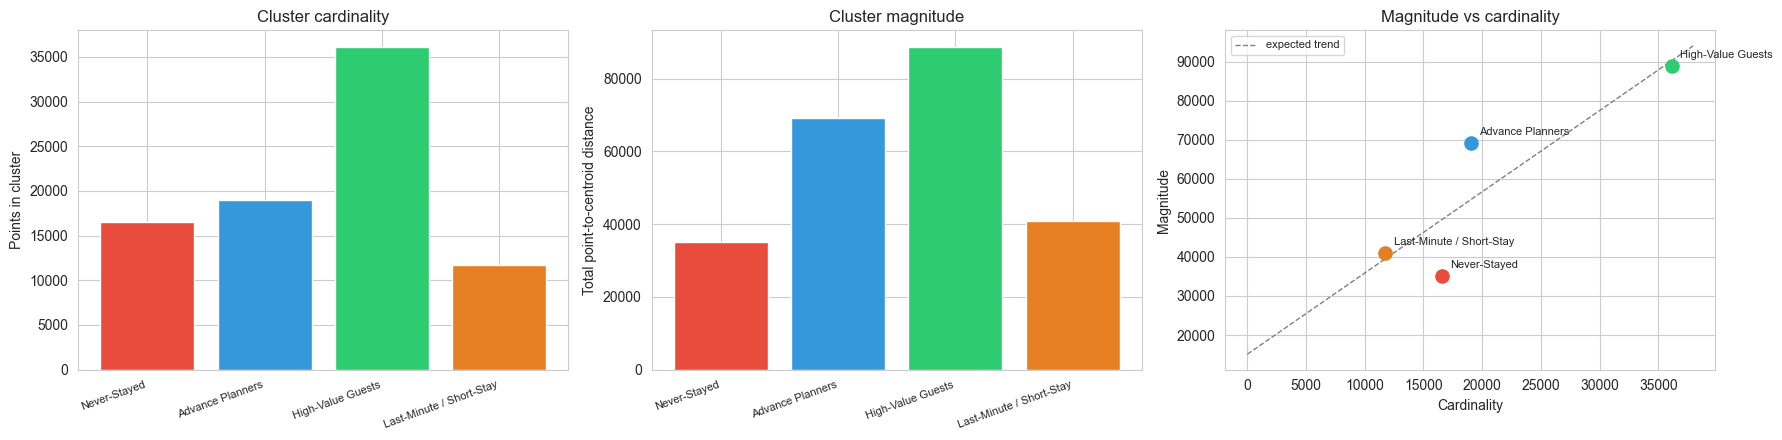

In [54]:
# Measured in the PCA space the clustering actually used, so it is consistent with
# how the clusters were formed.
labels  = df_prep['Cluster'].values
centers = kmeans.cluster_centers_
pts     = X_pca[pc_cols].values

cardinality = np.array([(labels == k).sum() for k in range(4)])
magnitude   = np.array([np.linalg.norm(pts[labels == k] - centers[k], axis=1).sum()
                        for k in range(4)])

quality = pd.DataFrame({
    'Segment'        : [cluster_names[k] for k in range(4)],
    'Cardinality'    : cardinality,
    'Magnitude'      : magnitude.round(0).astype(int),
    'AvgDistToCenter': (magnitude / cardinality).round(3),   # compactness per point
})

# Expected magnitude from the cardinality trend; large residuals = anomalous clusters
slope, intercept = np.polyfit(cardinality, magnitude, 1)
quality['Residual'] = (magnitude - (slope * cardinality + intercept)).round(0).astype(int)
print(quality.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
colors = [cluster_colors[k] for k in range(4)]
names  = [cluster_names[k] for k in range(4)]

axes[0].bar(range(4), cardinality, color=colors)
axes[0].set_title('Cluster cardinality'); axes[0].set_ylabel('Points in cluster')
axes[0].set_xticks(range(4)); axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=8)

axes[1].bar(range(4), magnitude, color=colors)
axes[1].set_title('Cluster magnitude'); axes[1].set_ylabel('Total point-to-centroid distance')
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)

xs = np.linspace(0, cardinality.max() * 1.05, 100)
axes[2].plot(xs, slope * xs + intercept, color='grey', ls='--', lw=1, label='expected trend')
for k in range(4):
    axes[2].scatter(cardinality[k], magnitude[k], color=cluster_colors[k], s=90, zorder=3)
    axes[2].annotate(cluster_names[k], (cardinality[k], magnitude[k]),
                     fontsize=8, xytext=(6, 6), textcoords='offset points')
axes[2].set_title('Magnitude vs cardinality'); axes[2].set_xlabel('Cardinality')
axes[2].set_ylabel('Magnitude'); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Observation - Cardinality vs Magnitude.** 

Magnitude tracks cardinality well for High-Value and Last-Minute/Short-Stay - both sit on the trend line, so they are about as compact as their size implies. Two clusters depart from it. **Never-Stayed** has far *lower* magnitude than its size predicts (average point-to-centroid distance ≈ 2.1, the tightest cluster): expected, since these customers are near-identical on every behavioural feature (zeros plus the recency sentinel), so they pack tightly together. **Advance Planners** is the opposite - *higher* magnitude than its size predicts (average distance ≈ 3.6, the loosest cluster), which signals internal heterogeneity and matches its 'average-spend, books-far-ahead' profile likely mixing finer sub-behaviours. By this check, Advance Planners is the cluster a follow-up sub-segmentation would target first; the large High-Value group, despite its size, is comparatively compact.

### 4.4 - Alternative Models - Hierarchical & DBSCAN

### Why a second model here, and why Hierarchical and DBSCAN?

> One algorithm should not be trusted blindly. We re-cluster the same PCA space
> with two very different methods - **hierarchical (Ward)** and **DBSCAN** - to
> test whether the four-segment structure is real or just an artefact of K-Means.
> Each is tuned (the linkage rule for hierarchical, `eps` and `min_samples` for
> DBSCAN) and all three are then compared on Silhouette, Calinski–Harabasz and
> Davies–Bouldin before the final model is chosen.

#### Hierarchical Clustering

K-Means is not the only option, and a single algorithm should not be trusted blindly. We benchmark the K=4 K-Means solution against two alternative algorithm families and then choose between them on both statistical and business grounds.

The first alternative is **agglomerative hierarchical clustering** with Ward linkage, which merges customers bottom-up and lets us read a natural number of groups from the resulting dendrogram. Hierarchical clustering builds an O(n²) distance structure, so fitting it on all 83,510 customers is infeasible in memory. We therefore work on a representative random sample (fixed seed for
reproducibility), standard practice for hierarchical methods on large data.

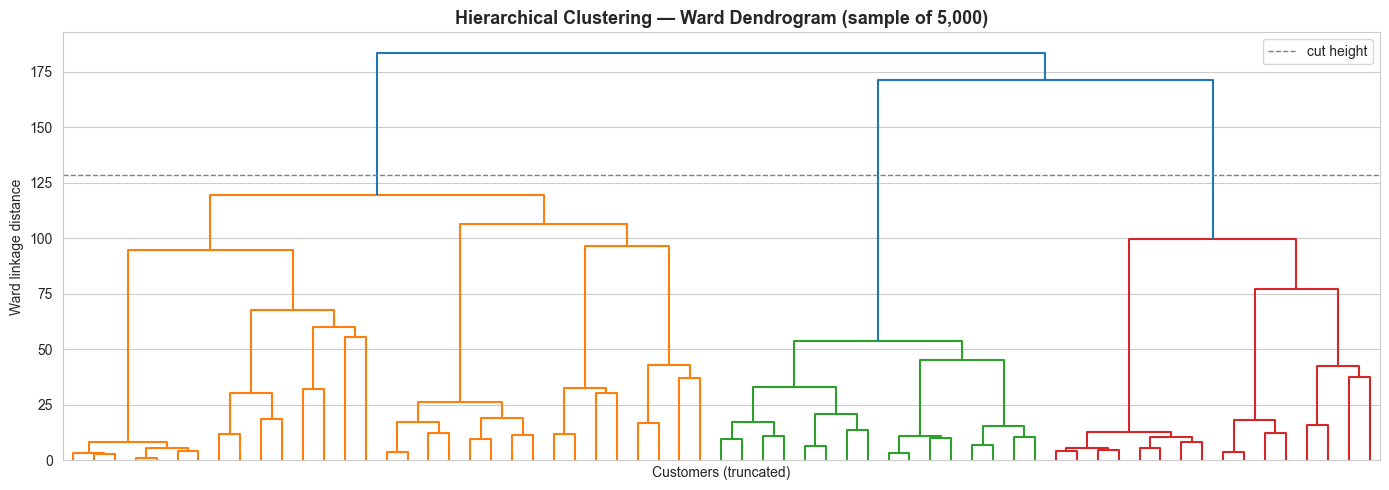

Hierarchical (k=4) cluster sizes on the sample:
0    1156
1     677
2     951
3    2216
Silhouette (sample): 0.3074


In [55]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

pc_cols = [col for col in X_pca.columns if col.startswith('PC')]

# Representative sample (hierarchical clustering is O(n^2) in memory)
rng = np.random.RandomState(123)
dendro_idx = rng.choice(len(X_pca), 5000, replace=False)
dendro_sample = X_pca[pc_cols].values[dendro_idx]

# Ward linkage minimises within-cluster variance, the natural analogue of K-Means
Z = linkage(dendro_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True,
           color_threshold=0.7 * max(Z[:, 2]))
plt.axhline(0.7 * max(Z[:, 2]), color='grey', linestyle='--', linewidth=1,
            label='cut height')
plt.title('Hierarchical Clustering — Ward Dendrogram (sample of 5,000)',
          fontsize=13, fontweight='bold')
plt.xlabel('Customers (truncated)')
plt.ylabel('Ward linkage distance')
plt.legend()
plt.tight_layout()
plt.show()

# Fit a 4-cluster solution on the sample to compare against K-Means
hier_labels = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(dendro_sample)
print('Hierarchical (k=4) cluster sizes on the sample:')
print(pd.Series(hier_labels).value_counts().sort_index().to_string())
print(f'Silhouette (sample): {silhouette_score(dendro_sample, hier_labels):.4f}')

**Why this step (testing the parameters).** Hierarchical clustering needs a *linkage* rule - how the distance between two groups is measured. We try the three common options at k=4 and look at both the silhouette and the resulting cluster sizes, because a good score with badly balanced clusters is not a usable segmentation.

In [56]:
# Compare linkage rules at k=4 on the same sample
link_results = []
for link in ['ward', 'complete', 'average']:
    lab = AgglomerativeClustering(n_clusters=4, linkage=link).fit_predict(dendro_sample)
    link_results.append([link, round(silhouette_score(dendro_sample, lab), 4),
                          np.bincount(lab).tolist()])
print(pd.DataFrame(link_results, columns=['Linkage', 'Silhouette', 'Cluster sizes']
                   ).to_string(index=False))

 Linkage  Silhouette          Cluster sizes
    ward      0.3074 [1156, 677, 951, 2216]
complete      0.1665    [4615, 326, 28, 31]
 average      0.3939     [4919, 22, 28, 31]


**Observation - Linkage Choice** 

`average` linkage posts the highest silhouette, but it is degenerate, one cluster holds almost all customers while the others are tiny, which is useless for marketing. `ward` produces four balanced, usable groups, so we use Ward. This is a good reminder that a higher silhouette is not automatically
a better segmentation; the cluster sizes have to make business sense too.

**Observation - Dendrogram** 

The dendrogram shows a small number of well-separated branches at the top, and cutting it into four groups gives a silhouette close to the K-Means value. Crucially, an algorithm with a different mechanism arrives at roughly the same four-way structure - early evidence that the four-segment solution reflects real structure in the data rather than something K-Means imposed through its own assumptions.

#### DBSCAN

The second alternative is **DBSCAN**, a density-based algorithm. Unlike K-Means and hierarchical clustering it does not take the number of clusters as input,it discovers clusters as dense regions and labels sparse points as *noise*. It needs two parameters: `min_samples` (we use 20, roughly twice the dimensionality of the 10-component PCA space) and `eps`, the neighbourhood radius. `eps` is tuned with a **k-distance plot**: we sort every point by the distance to its 20-th nearest neighbour and look for the "knee", the radius at which distances start to grow sharply.

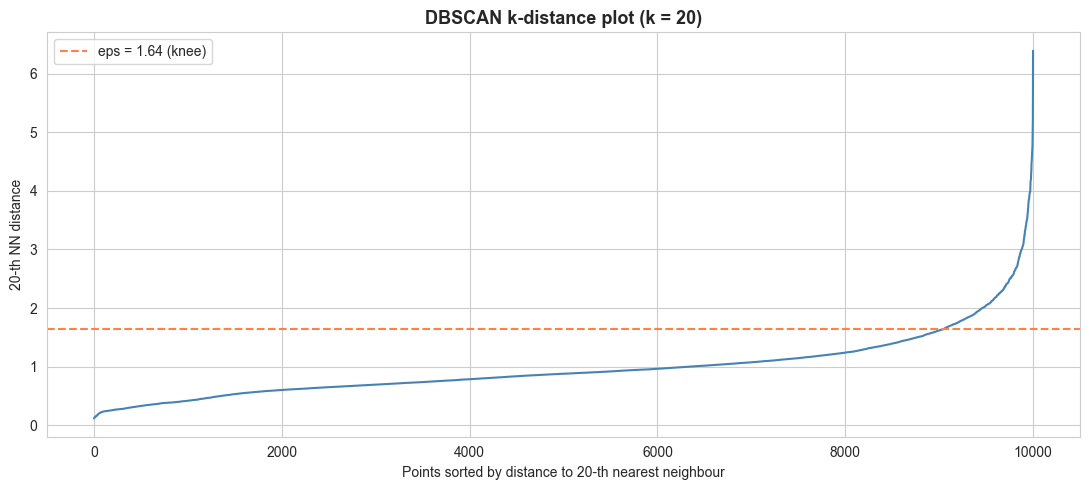

DBSCAN(eps=1.64, min_samples=20) on a 10,000-customer sample:
  clusters found : 18
  noise points   : 4.7%
  silhouette (excl. noise): 0.3346


In [57]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

rng = np.random.RandomState(123)
db_idx = rng.choice(len(X_pca), 10000, replace=False)
db_sample = X_pca[pc_cols].values[db_idx]

min_samples = 20  # ~ 2 x dimensionality (10 principal components)
nn = NearestNeighbors(n_neighbors=min_samples).fit(db_sample)
dist, _ = nn.kneighbors(db_sample)
k_dist = np.sort(dist[:, min_samples - 1])

# Automatic knee detection: the point on the sorted curve farthest from the
# straight line joining its first and last point (deterministic, no extra deps).
x = np.arange(len(k_dist))
x1, y1, x2, y2 = x[0], k_dist[0], x[-1], k_dist[-1]
chord = (np.abs((y2 - y1) * x - (x2 - x1) * k_dist + x2 * y1 - y2 * x1)
         / np.hypot(y2 - y1, x2 - x1))
eps = round(float(k_dist[np.argmax(chord)]), 2)

plt.figure(figsize=(11, 5))
plt.plot(k_dist, color='steelblue')
plt.axhline(eps, color='coral', linestyle='--', label=f'eps = {eps} (knee)')
plt.title(f'DBSCAN k-distance plot (k = {min_samples})', fontsize=13, fontweight='bold')
plt.xlabel(f'Points sorted by distance to {min_samples}-th nearest neighbour')
plt.ylabel(f'{min_samples}-th NN distance')
plt.legend()
plt.tight_layout()
plt.show()

dbscan_labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(db_sample)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_pct = (dbscan_labels == -1).mean() * 100
print(f'DBSCAN(eps={eps}, min_samples={min_samples}) on a 10,000-customer sample:')
print(f'  clusters found : {n_clusters_db}')
print(f'  noise points   : {noise_pct:.1f}%')
mask = dbscan_labels != -1
if len(set(dbscan_labels[mask])) > 1:
    print(f'  silhouette (excl. noise): {silhouette_score(db_sample[mask], dbscan_labels[mask]):.4f}')

**Why this step (testing the parameters)** DBSCAN's result depends entirely on
`eps` and `min_samples`. Before trusting the single knee value, we scan a small
grid to see how the number of clusters and the share of "noise" customers react.
This shows the choice is informed, not arbitrary.

In [58]:
# Test how DBSCAN reacts to its two parameters (reuses the 10k sample above)
grid = []
for ms in [10, 20, 30]:
    for e in [1.5, 2.0, 2.5, 3.0]:
        lab = DBSCAN(eps=e, min_samples=ms).fit_predict(db_sample)
        n_clust = len(set(lab)) - (1 if -1 in lab else 0)
        grid.append([e, ms, n_clust, round((lab == -1).mean() * 100, 1)])

print('DBSCAN parameter grid (sample of 10,000):')
print(pd.DataFrame(grid, columns=['eps', 'min_samples', 'clusters', 'noise_%']
                   ).to_string(index=False))
print('\nNo setting gives a small number of clean, well-sized clusters: low eps '
      'creates many fragments and lots of noise, high eps collapses everything '
      'into a few groups. This is the core reason DBSCAN does not suit this data.')

DBSCAN parameter grid (sample of 10,000):
 eps  min_samples  clusters  noise_%
 1.5           10        23      3.9
 2.0           10        13      1.2
 2.5           10         8      0.4
 3.0           10         6      0.1
 1.5           20        19      6.0
 2.0           20        10      2.2
 2.5           20         6      0.9
 3.0           20         4      0.5
 1.5           30        15      8.6
 2.0           30         8      3.2
 2.5           30         6      1.3
 3.0           30         4      0.6

No setting gives a small number of clean, well-sized clusters: low eps creates many fragments and lots of noise, high eps collapses everything into a few groups. This is the core reason DBSCAN does not suit this data.


**Observation - DBSCAN Results** 

At the knee-selected `eps`, DBSCAN fragments the data into roughly ten clusters and labels a few percent of customers as noise. Its silhouette looks attractive, but it is computed only on the non-noise points, which flatters the score, and the result does not match the business need: ten
micro-segments plus an unassigned "noise" group cannot be turned into a small set of marketing playbooks. Density-based clustering simply does not fit this data, whose structure is a few broad behavioural gradients rather than tight, well-separated dense blobs.

#### Model Comparison and Selection

Finally we compare the three algorithms on a **common 10,000-customer sample**, so the metrics are directly comparable, using three internal validation indices:

| Index | Better when | Measures |
|-------|------------|----------|
| Silhouette | Higher (range -1 to 1) | How well separated the clusters are. |
| Calinski-Harabasz | Higher | Between- vs within-cluster dispersion. |
| Davies-Bouldin | Lower | Average similarity between each cluster and its most similar one. |

Model comparison on a common 10,000-customer sample
(Silhouette & Calinski-Harabasz: higher = better; Davies-Bouldin: lower = better)

                   Model  Clusters  Noise_%  Silhouette  Calinski-Harabasz  Davies-Bouldin
           K-Means (k=4)         4      0.0       0.308             2490.0           1.617
Hierarchical (k=4, ward)         4      0.0       0.306             2459.0           1.622
       DBSCAN (eps=1.64)        18      4.7       0.335             1752.0           0.966


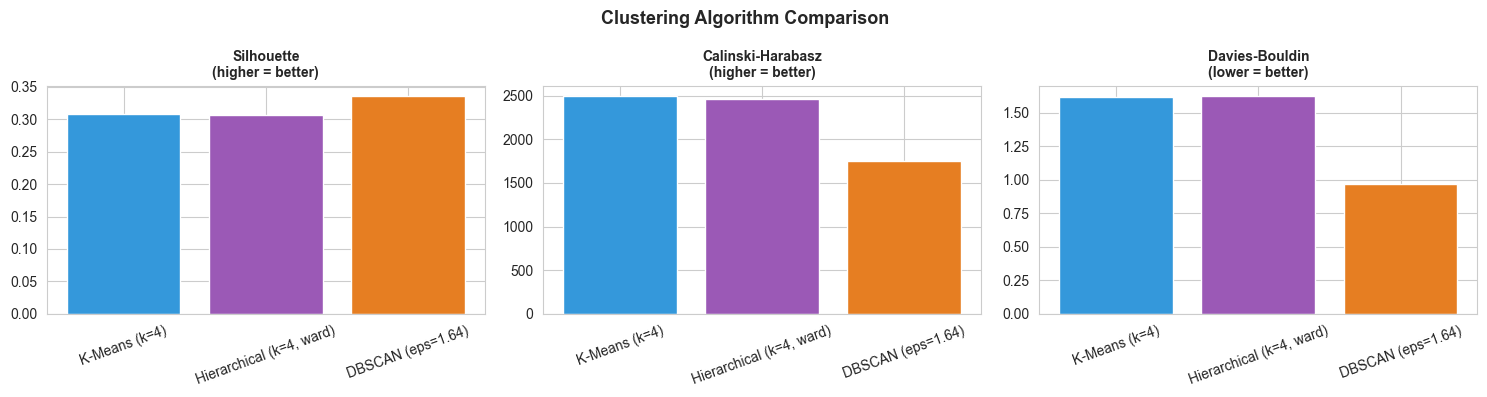

In [59]:
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score)

rng = np.random.RandomState(123)
comp_idx = rng.choice(len(X_pca), 10000, replace=False)
Xc = X_pca[pc_cols].values[comp_idx]

# Fit every algorithm on the SAME sample so the scores are comparable
km_lab   = KMeans(n_clusters=4, init='k-means++', n_init=10,
                  random_state=123).fit_predict(Xc)
hier_lab = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(Xc)
db_lab   = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xc)


def score_model(name, labels, X):
    mask = labels != -1                       # ignore DBSCAN noise for metrics
    k = len(set(labels[mask]))
    noise = round((labels == -1).mean() * 100, 1)
    if k < 2:
        return [name, k, noise, np.nan, np.nan, np.nan]
    return [name, k, noise,
            round(silhouette_score(X[mask], labels[mask]), 3),
            round(calinski_harabasz_score(X[mask], labels[mask]), 0),
            round(davies_bouldin_score(X[mask], labels[mask]), 3)]


comparison = pd.DataFrame(
    [score_model('K-Means (k=4)', km_lab, Xc),
     score_model('Hierarchical (k=4, ward)', hier_lab, Xc),
     score_model(f'DBSCAN (eps={eps})', db_lab, Xc)],
    columns=['Model', 'Clusters', 'Noise_%', 'Silhouette',
             'Calinski-Harabasz', 'Davies-Bouldin'])

print('Model comparison on a common 10,000-customer sample')
print('(Silhouette & Calinski-Harabasz: higher = better; Davies-Bouldin: lower = better)\n')
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bar_colors = ['#3498db', '#9b59b6', '#e67e22']
for ax, col, better in zip(axes,
                           ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin'],
                           ['higher', 'higher', 'lower']):
    ax.bar(comparison['Model'], comparison[col], color=bar_colors, edgecolor='white')
    ax.set_title(f'{col}\n({better} = better)', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Clustering Algorithm Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation - Model Selection**

No algorithm wins on every metric. DBSCAN has the best silhouette and Davies–Bouldin,
but only by making ~10 clusters and dropping ~3% as noise (and its silhouette ignores
that noise, which flatters it). Hierarchical (Ward) and K-Means are close on
silhouette; K-Means leads on Calinski–Harabasz and Davies–Bouldin.

So the choice is driven by fit, not just the numbers:
- **Segments:** the brief wants 3–7. K-Means and Hierarchical give 4; DBSCAN's ~10 + a noise class are unusable for marketing.
- **Scale:** Hierarchical is O(n²) and can't run on all 83,510 rows; K-Means can.
- **New customers:** only K-Means has `predict()` to score new arrivals (used in Part 6).
- **Reproducibility:** K-Means with a fixed seed reproduces exactly and is simple to maintain.

**K-Means (K=4) is the deployed model.** When asked for four clusters, Hierarchical
(Ward) lands on a near-identical silhouette, and the dendrogram in 4.3 shows a small
number of well-separated branches at a comparable cut. Note that we *fixed* k=4 for
the comparison, so this is corroboration of the four-segment structure, not an
independent rediscovery of the number four. Taken together it is reasonable evidence
the segmentation is real rather than a K-Means artefact. The profiling below uses the
K-Means labels.

### 4.5 - Integrated Pattern Summary - Deep Dive into the Never-Stayed Segment

Before passing the segmentation results to Part 5, it is worth investigating the Never-Stayed segment more closely. A segment representing 19.9% of the customer base that generates zero revenue is not simply a statistical artefact to be noted and set aside - it is a business problem that the 
current segmentation has been hiding.

The question is not just that these customers never stayed. The question is why.

In [60]:
# Export cluster assignments for Part 5
output = df_clean.copy()
output['Cluster']      = df_prep['Cluster'].values
output['ClusterName']  = output['Cluster'].map(cluster_names)

output.to_csv('hotel_clustered.csv', index=False)

print('Cluster assignments exported to hotel_clustered.csv')
print()
print('=== Final Summary ===')
print(f'Total customers  : {len(output):,}')
print(f'Algorithm        : K-Means (K=4)')
print(f'PCA components   : 10 (84.0% variance)')
print(f'Silhouette score : {sil:.4f}')
print()
for c in range(4):
    n   = (output['Cluster'] == c).sum()
    pct = n / len(output) * 100
    print(f'Cluster {c} — {cluster_names[c]:<25}: {n:>6,} customers ({pct:.1f}%)')

Cluster assignments exported to hotel_clustered.csv

=== Final Summary ===
Total customers  : 83,510
Algorithm        : K-Means (K=4)
PCA components   : 10 (84.0% variance)
Silhouette score : 0.3075

Cluster 0 — Never-Stayed             : 16,569 customers (19.8%)
Cluster 1 — Advance Planners         : 19,027 customers (22.8%)
Cluster 2 — High-Value Guests        : 36,157 customers (43.3%)
Cluster 3 — Last-Minute / Short-Stay : 11,757 customers (14.1%)


In [61]:
# Investigate the Never-Stayed segment (id derived in the K-Means cell)
c3 = df_clean[df_prep['Cluster'] == never_id]

print('=== Never-Stayed Segment Investigation ===')
print(f'Total customers: {len(c3):,}')
print()

# Distribution Channel
print('Distribution Channel:')
print(c3['DistributionChannel'].value_counts())
print()

# Market Segment  
print('Market Segment:')
print(c3['MarketSegment'].value_counts())
print()

# Top Nationalities
print('Top 10 Nationalities:')
print(c3['Nationality'].value_counts().head(10))
print()

# Bookings Canceled vs NoShowed
print('BookingsCanceled:')
print(c3['BookingsCanceled'].value_counts().head())
print()
print('BookingsNoShowed:')
print(c3['BookingsNoShowed'].value_counts().head())
print()

# Age distribution
print('Age stats:')
print(c3['Age'].describe().round(1))
print()

# DaysSinceCreation — how recently did they register?
print('DaysSinceCreation (days since registered):')
print(c3['DaysSinceCreation'].describe().round(1))

=== Never-Stayed Segment Investigation ===
Total customers: 16,569

Distribution Channel:
DistributionChannel
Travel Agent/Operator      16255
Corporate                    231
Direct                        63
Electronic Distribution       20
Name: count, dtype: int64

Market Segment:
MarketSegment
Other                    12271
Travel Agent/Operator     2380
Groups                    1633
Corporate                  186
Direct                      78
Complementary               17
Aviation                     4
Name: count, dtype: int64

Top 10 Nationalities:
Nationality
FRA    2549
DEU    2045
GBR    1815
PRT    1455
USA     791
BRA     770
ESP     738
ITA     671
BEL     619
NLD     584
Name: count, dtype: int64

BookingsCanceled:
BookingsCanceled
0    16569
Name: count, dtype: int64

BookingsNoShowed:
BookingsNoShowed
0    16569
Name: count, dtype: int64

Age stats:
count    15806.0
mean        40.2
std         19.6
min         -7.0
25%         26.0
50%         42.0
75%         55.0


In [62]:
# Compare Never-Stayed vs Has-Stayed within Travel Agent/Operator channel
ta_stayed     = df_clean[(df_prep['Cluster'] != never_id) & 
                   (df_clean['DistributionChannel'] == 'Travel Agent/Operator')]
ta_not_stayed = c3[c3['DistributionChannel'] == 'Travel Agent/Operator']

print('=== Travel Agent/Operator: Stayed vs Never-Stayed ===')
print(f'Stayed        : {len(ta_stayed):,}')
print(f'Never-Stayed  : {len(ta_not_stayed):,}')
print(f'Non-conversion rate: {len(ta_not_stayed)/(len(ta_stayed)+len(ta_not_stayed))*100:.1f}%')
print()

# AverageLeadTime comparison
print('AverageLeadTime (days before arrival):')
print(f'  Stayed      : {ta_stayed["AverageLeadTime"].mean():.1f} days')
print(f'  Never-Stayed: {df_clean.loc[df_prep["Cluster"]==never_id, "AverageLeadTime"].mean():.1f} days')
print()

# DaysSinceCreation comparison
print('DaysSinceCreation (how long in database):')
print(f'  Stayed      : {ta_stayed["DaysSinceCreation"].mean():.1f} days')
print(f'  Never-Stayed: {c3["DaysSinceCreation"].mean():.1f} days')
print()

# Nationality overlap
print('Top 5 nationalities — Never-Stayed:')
print(c3['Nationality'].value_counts().head(5))
print()
print('Top 5 nationalities — Stayed (TA/Operator):')
print(ta_stayed['Nationality'].value_counts().head(5))

=== Travel Agent/Operator: Stayed vs Never-Stayed ===
Stayed        : 52,242
Never-Stayed  : 16,255
Non-conversion rate: 23.7%

AverageLeadTime (days before arrival):
  Stayed      : 94.4 days
  Never-Stayed: 0.0 days

DaysSinceCreation (how long in database):
  Stayed      : 533.6 days
  Never-Stayed: 219.7 days

Top 5 nationalities — Never-Stayed:
Nationality
FRA    2549
DEU    2045
GBR    1815
PRT    1455
USA     791
Name: count, dtype: int64

Top 5 nationalities — Stayed (TA/Operator):
Nationality
FRA    8137
DEU    7112
PRT    6393
GBR    5598
ESP    3066
Name: count, dtype: int64


**Observation - Channel Analysis**

The make-up of the Never-Stayed segment points to a process issue, not customer behaviour. 98.1% came through Travel Agent/Operator channels and 74.1% sit in the vague "Other" segment (typical of OTA provisional registrations). There were zero cancellations and zero no-shows across all 16,632 - these bookings were never cancelled because they were never confirmed.

The top nationalities (French, German, British, Portuguese) are identical to those of guests who *did* stay. So it is the right audience failing at conversion, not the wrong audience - exactly the blind spot manager A flagged: an origin-based segmentation can't tell a completed stay from a provisional registration, yet 23.8% of Travel Agent customers generate zero revenue.

#### Critical Finding - Zero Lead Time as a Conversion Signal

The comparison isolates one variable: lead time. Guests who stayed booked ~94 days ahead; Never-Stayed customers show 0 days, the record was created on the arrival date or with no date at all. That is a registration placeholder from an intermediary, not a real booking. The result is a structural ~23.7% non-conversion rate in the Travel Agent channel, thousands of lost stays a year from an audience identical to the paying one.

Three responses follow:
1. **CRM filter:** flag Travel Agent registrations with lead time below ~7 days as unconfirmed until a deposit arrives.
2. **Partner deposits:** require a non-refundable deposit within 48h from high-volume travel-agent partners.
3. **Direct re-engagement:** invite the Never-Stayed nationalities (FR, DE, GB, PT) to complete the booking directly.

#### Conclusion

Four behaviorally distinct customer segments emerge from this analysis, each with a fundamentally different commercial relationship with the hotel. The segmentation meets all project criteria - silhouette score of 0.3075, every cluster above 1% of the database, and clear interpretability at the segment level.

The most consequential finding is structural: nearly one in five customers has never completed a stay, and the reason is traceable to a single measurable variable - lead time. This problem was invisible under the current origin-based segmentation and is now, for the first time, quantified and actionable.

---

## Part 5 - Evaluation


This phase does **not** re-run the model. Its job is to *evaluate* that result against the business problem A defined in Part 1:

1. **Profile** each cluster on the variables that matter commercially (central
   tendency per segment).
2. **Name and interpret** each segment so a non-technical reader understands who
   it is.
3. Derive **segment-specific marketing recommendations** (channel, pricing,
   targeting).
4. Check the result against the **success criteria** set in Part 1.

**Design choice - why we reload from `hotel_clustered.csv` instead of reusing the in-memory `df_prep`.** Reading the exported file makes this section reproducible and self-contained: it can be re-run on its own without first executing Parts 2–4, and it guarantees the evaluation is performed on exactly the cluster labels that were saved, not on a possibly re-fitted model. The few engineered features needed for profiling are reconstructed below with the identical logic used in Part 3, so the numbers are consistent across the notebook.

### 5.1 - Setup and Feature Reconstruction

We load the exported assignments and rebuild the cleaned/engineered features that
profiling depends on. Each transformation mirrors Part 3 exactly (`Age` cleaning,
sentinel handling, 99th-percentile capping, and the engineered value features).
Wrapping it in a single function keeps the logic in one place and makes the
intent auditable.

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_STATE = 123  # single source of truth for reproducibility (see Part 6)

# Profiling reuses the in-memory data from Parts 3-4 — no second read of the TSV/CSV
# and no repeated preparation. We build the profiling frame once with prepare_features()
# (it needs the engineered features on their original, unscaled scale, which the encoded
# model matrix no longer carries) and attach the cluster labels found in Part 4.
profile_df = prepare_features(df_clean)
profile_df['Cluster'] = df_prep['Cluster'].values

print(f'Customers profiled : {len(profile_df):,}')
print(f'Clusters found     : {sorted(profile_df["Cluster"].unique())}')
print(profile_df['Cluster'].value_counts().sort_index())

Customers profiled : 83,510
Clusters found     : [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Cluster
0    16569
1    19027
2    36157
3    11757
Name: count, dtype: int64


### 5.2 - Data-Driven Segment Naming

**Why we name segments from their statistics rather than hard-coding cluster numbers.** K-Means assigns *arbitrary integer labels* to clusters. The integer that comes out as "cluster 0" can change between scikit-learn versions or runs even with a fixed `random_state`, so hard-coding `0 = High-Value` is a silent reproducibility bug: the label could attach to the wrong group on someone else's machine. Instead we derive each name from the cluster's own profile, so the name always follows the behaviour:

- **Never-Stayed** - the cluster with the lowest `HasStayed` (≈ 0, never converted).
- **High-Value Guests** - the cluster with the highest `TotalRevenue`.
- The two remaining clusters have nearly identical revenue, so we separate them by
  booking horizon: the one with the **longer average lead time** is **Advance Planners**,
  the **shorter-lead** one is **Last-Minute / Short-Stay**.

In [64]:
profile_cols = ['Age', 'TotalRevenue', 'LodgingRevenue', 'OtherRevenue',
                'AvgRevenuePerNight', 'RevenuePerBooking', 'BookingsCheckedIn',
                'AverageLeadTime', 'RoomNights', 'PersonsNights',
                'DaysSinceLastStay', 'TotalSpecialRequests', 'HasStayed']

cluster_means = profile_df.groupby('Cluster')[profile_cols].mean()

# Derive the label -> name mapping from behaviour (order-independent, version-safe)
never_id      = cluster_means['HasStayed'].idxmin()
high_id       = cluster_means['TotalRevenue'].idxmax()
remaining     = [c for c in cluster_means.index if c not in (never_id, high_id)]
# name the two remaining clusters by booking horizon (their revenue is near-identical)
planner_id    = cluster_means.loc[remaining, 'AverageLeadTime'].idxmax()
lastminute_id = [c for c in remaining if c != planner_id][0]

segment_map = {
    high_id:       'High-Value Guests',
    planner_id:    'Advance Planners',
    lastminute_id: 'Last-Minute / Short-Stay',
    never_id:      'Never-Stayed',
}

# Fixed colour per segment for consistent visuals throughout Part 5
segment_colors = {
    'High-Value Guests':        '#2ecc71',
    'Advance Planners':         '#3498db',
    'Last-Minute / Short-Stay': '#e67e22',
    'Never-Stayed':             '#e74c3c',
}

profile_df['Segment'] = profile_df['Cluster'].map(segment_map)

print('Cluster label -> Segment name')
for cid, name in segment_map.items():
    n = (profile_df['Cluster'] == cid).sum()
    print(f'  Cluster {cid}: {name:<22} ({n:,} customers, {n/len(profile_df)*100:.1f}%)')

Cluster label -> Segment name
  Cluster 2: High-Value Guests      (36,157 customers, 43.3%)
  Cluster 1: Advance Planners       (19,027 customers, 22.8%)
  Cluster 3: Last-Minute / Short-Stay (11,757 customers, 14.1%)
  Cluster 0: Never-Stayed           (16,569 customers, 19.8%)


### 5.3 - Cluster Profiling - Central Tendency per Segment

We report both the **mean** and the **median** for every key feature. The two
together are informative because several features are right-skewed even after
capping: where mean and median diverge sharply (revenue, room nights), the median
describes the typical customer while the mean is pulled up by the segment's
heaviest spenders. A row for the overall population is appended for reference.

In [65]:
segment_order = ['High-Value Guests', 'Advance Planners',
                 'Last-Minute / Short-Stay', 'Never-Stayed']

mean_profile = profile_df.groupby('Segment')[profile_cols].mean().round(2)
mean_profile = mean_profile.reindex(segment_order)
mean_profile.loc['Overall'] = profile_df[profile_cols].mean().round(2)

median_profile = profile_df.groupby('Segment')[profile_cols].median().round(2)
median_profile = median_profile.reindex(segment_order)
median_profile.loc['Overall'] = profile_df[profile_cols].median().round(2)

print('=== MEAN profile per segment ===')
print(mean_profile.T.to_string())
print('\n=== MEDIAN profile per segment ===')
print(median_profile.T.to_string())

=== MEAN profile per segment ===
Segment               High-Value Guests  Advance Planners  Last-Minute / Short-Stay  Never-Stayed  Overall
Age                               45.56             50.93                     42.64         40.51    45.37
TotalRevenue                     517.54            363.72                    350.80          0.00   356.34
LodgingRevenue                   429.62            285.11                    289.04          0.00   291.66
OtherRevenue                      87.92             78.60                     61.77          0.00    64.67
AvgRevenuePerNight               170.08            122.53                    126.30          0.00   119.34
RevenuePerBooking                510.25            352.99                    341.60          0.00   349.44
BookingsCheckedIn                  1.02              1.03                      0.74          0.00     0.78
AverageLeadTime                   79.93            109.46                     42.66          0.00    65.55
Room

**Observation - Profile Table** 

High-Value Guests have the highest value *per customer*, about 1.45× the average total revenue (≈ €518 vs €356) and the highest revenue per night, and they are also the largest stayed segment, so they dominate total revenue. Advance Planners sit close to the average on spend but are distinctive for booking the furthest ahead (≈ 110 days lead time) with few special requests. Last-Minute / Short-Stay customers book at short notice (≈ 40 days), take shorter stays, and include a sizeable share who never actually completed a stay. Never-Stayed customers are zero on every behavioural and value metric by construction, and only appear "high" on recency because of the sentinel replacement applied in Part 3.

### 5.4 - Profile Comparison - Grouped Bar Chart

To compare segments on features measured in different units (euros, days, counts)
we standardise each feature to its z-score relative to the overall mean. A bar
above zero means the segment is above the hotel average on that feature; below
zero means under-average. This puts every variable on a common scale so the
*shape* of each segment is directly comparable.

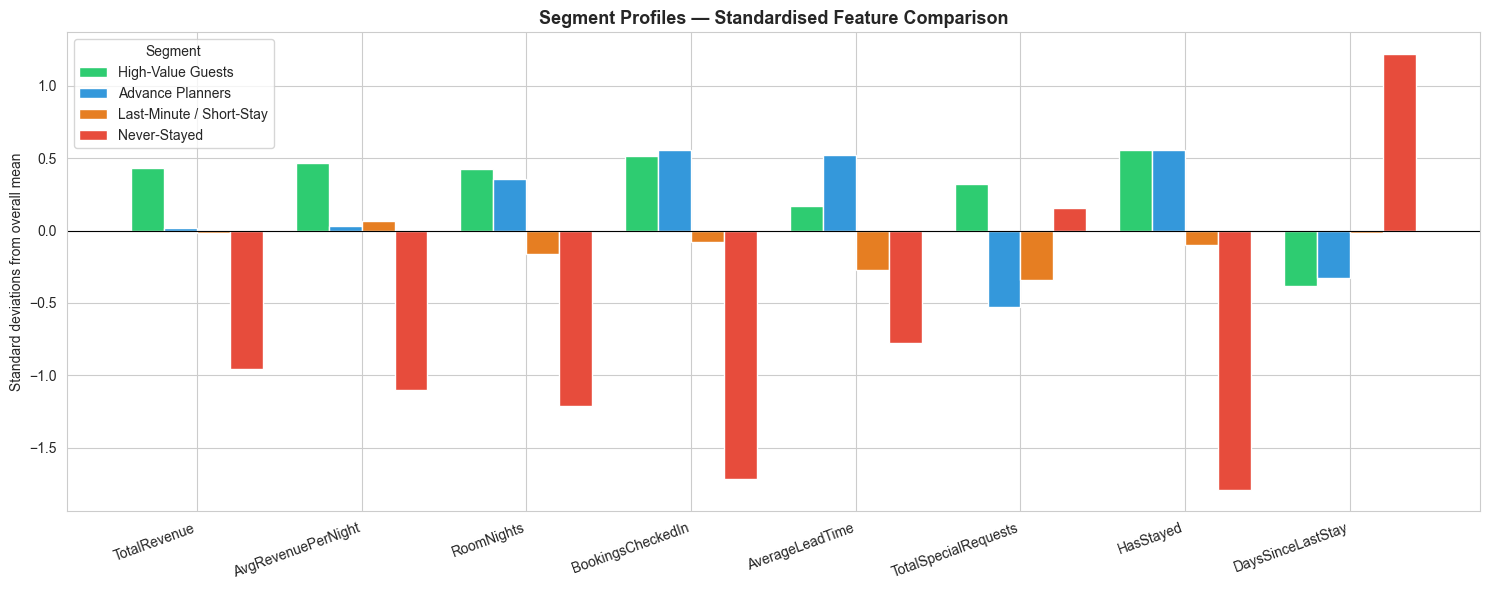

In [66]:
bar_feats = ['TotalRevenue', 'AvgRevenuePerNight', 'RoomNights',
             'BookingsCheckedIn', 'AverageLeadTime', 'TotalSpecialRequests',
             'HasStayed', 'DaysSinceLastStay']

seg_mean = profile_df.groupby('Segment')[bar_feats].mean().reindex(segment_order)
overall_mean = profile_df[bar_feats].mean()
overall_std  = profile_df[bar_feats].std()
z = (seg_mean - overall_mean) / overall_std   # standardised deviation

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(bar_feats))
width = 0.2
for i, seg in enumerate(segment_order):
    ax.bar(x + i * width, z.loc[seg], width,
           label=seg, color=segment_colors[seg], edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(bar_feats, rotation=20, ha='right')
ax.set_ylabel('Standard deviations from overall mean')
ax.set_title('Segment Profiles — Standardised Feature Comparison',
             fontsize=13, fontweight='bold')
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

**Observation - Profile Comparison**

On the z-scored bars the four segments separate cleanly. High-Value Guests sit above the population average on the value features (revenue, revenue per night, room nights). Advance Planners are near average on value but stand out for their long booking lead time. Last-Minute / Short-Stay guests fall below average on value and book at short notice. Never-Stayed customers are below average on every behavioural feature and only stand out on recency — a direct effect of the sentinel replacement rather than real recent activity.

### 5.5 - Segment Fingerprints - Radar Charts

Radar charts show the *whole behavioural fingerprint* of a segment at a glance.
Features are min-max scaled to 0–1 across segments so each axis is comparable. A
segment that fills the chart is strong on every dimension; a collapsed shape is
weak across the board.

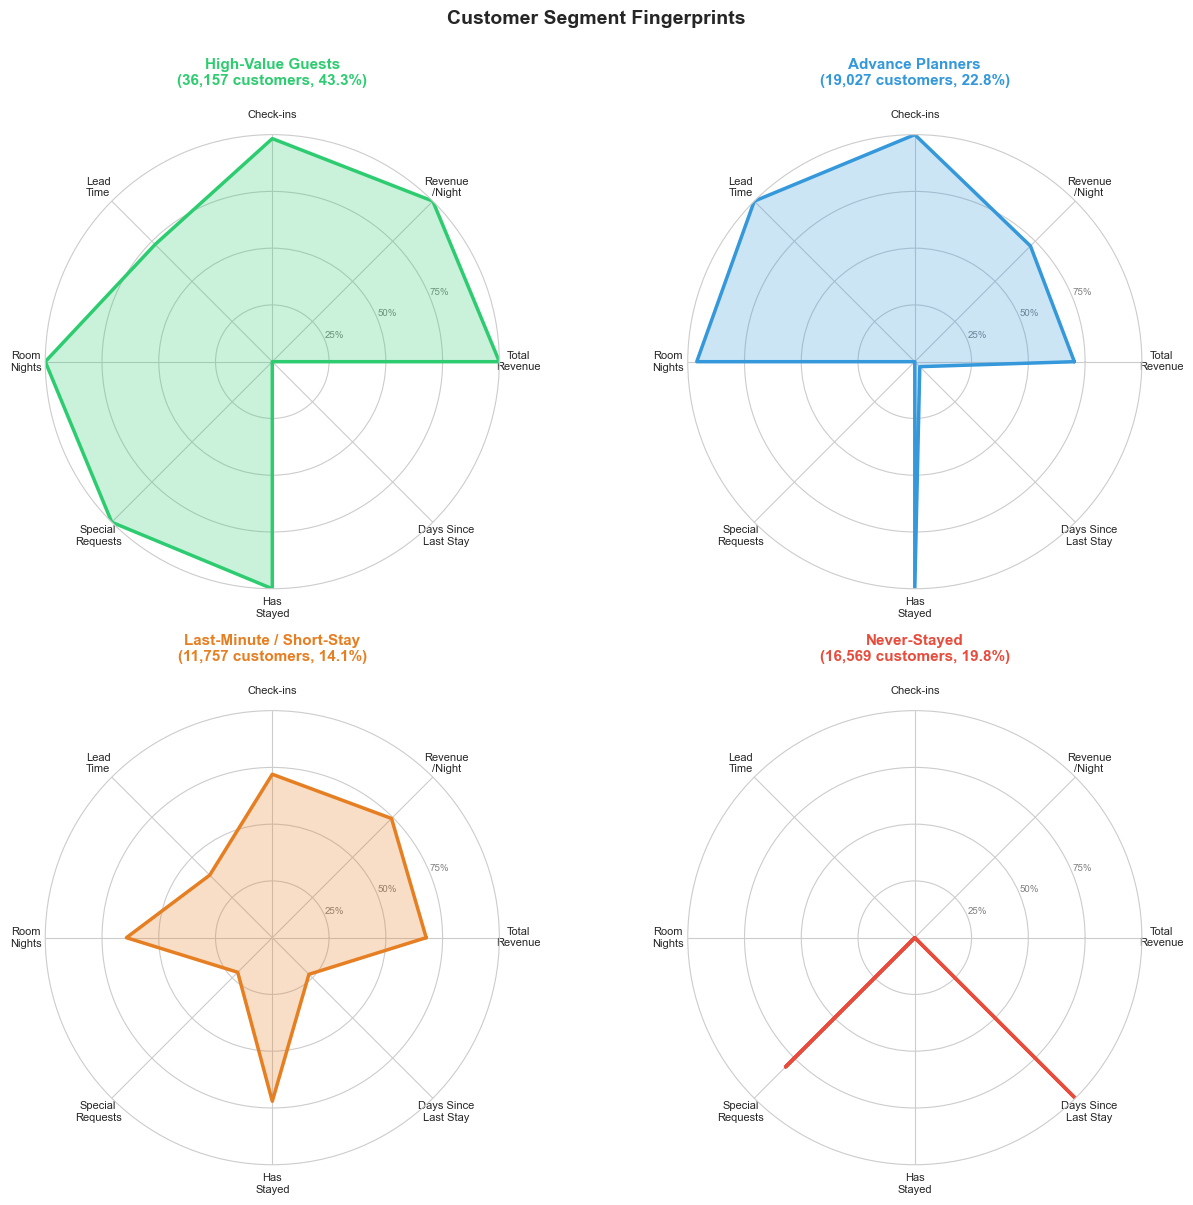

In [67]:
radar_feats = ['TotalRevenue', 'AvgRevenuePerNight', 'BookingsCheckedIn',
               'AverageLeadTime', 'RoomNights', 'TotalSpecialRequests',
               'HasStayed', 'DaysSinceLastStay']
radar_labels = ['Total\nRevenue', 'Revenue\n/Night', 'Check-ins', 'Lead\nTime',
                'Room\nNights', 'Special\nRequests', 'Has\nStayed',
                'Days Since\nLast Stay']

radar_src = profile_df.groupby('Segment')[radar_feats].mean().reindex(segment_order)
radar_norm = (radar_src - radar_src.min()) / (radar_src.max() - radar_src.min())

N = len(radar_feats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(2, 2, figsize=(13, 12), subplot_kw=dict(polar=True))
for ax, seg in zip(axes.ravel(), segment_order):
    vals = radar_norm.loc[seg].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=segment_colors[seg], linewidth=2.5)
    ax.fill(angles, vals, color=segment_colors[seg], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['25%', '50%', '75%'], fontsize=7, color='grey')
    n = (profile_df['Segment'] == seg).sum()
    ax.set_title(f'{seg}\n({n:,} customers, {n/len(profile_df)*100:.1f}%)',
                 fontsize=11, fontweight='bold', color=segment_colors[seg], pad=18)

plt.suptitle('Customer Segment Fingerprints', fontsize=14, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

**Observation - Segment Fingerprints**

Each segment has a distinct shape. High-Value Guests fill the radar most fully across the value dimensions, the ideal-guest fingerprint. Never-Stayed customers collapse to almost nothing on the behavioural axes. Advance Planners and Last-Minute / Short-Stay guests sit in between - Advance Planners stretched towards lead time, Last-Minute / Short-Stay smaller and more lopsided. The shapes restate the bar chart visually and confirm the segments differ both in kind (Never-Stayed vs the rest) and in degree.

### 5.6 - Revenue Contribution - Where the Money Actually Comes From

Segment *size* and segment *value* are different questions. This view contrasts
each segment's share of customers with its share of total revenue, which is the
single most decision-relevant output of the whole analysis for the marketing
budget.

                          Customers  CustomerShare_%  TotalRevenue  RevenueShare_%  MeanRevenue
Segment                                                                                        
High-Value Guests             36157             43.3    18712829.0            62.9        518.0
Advance Planners              19027             22.8     6920410.0            23.3        364.0
Last-Minute / Short-Stay      11757             14.1     4124409.0            13.9        351.0
Never-Stayed                  16569             19.8           0.0             0.0          0.0


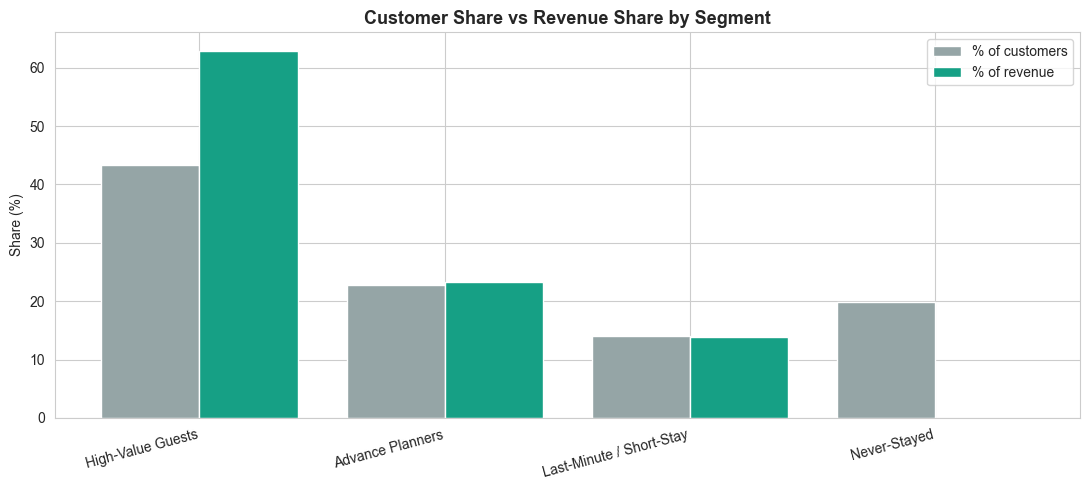

In [68]:
rev = profile_df.groupby('Segment').agg(
    Customers=('TotalRevenue', 'size'),
    TotalRevenue=('TotalRevenue', 'sum'),
    MeanRevenue=('TotalRevenue', 'mean'),
).reindex(segment_order)

rev['CustomerShare_%'] = (rev['Customers'] / rev['Customers'].sum() * 100).round(1)
rev['RevenueShare_%']  = (rev['TotalRevenue'] / rev['TotalRevenue'].sum() * 100).round(1)
rev['MeanRevenue'] = rev['MeanRevenue'].round(0)
rev['TotalRevenue'] = rev['TotalRevenue'].round(0)

print(rev[['Customers', 'CustomerShare_%', 'TotalRevenue',
           'RevenueShare_%', 'MeanRevenue']].to_string())

# Side-by-side share comparison
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(segment_order))
ax.bar(x - 0.2, rev['CustomerShare_%'], 0.4, label='% of customers',
       color='#95a5a6', edgecolor='white')
ax.bar(x + 0.2, rev['RevenueShare_%'], 0.4, label='% of revenue',
       color='#16a085', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(segment_order, rotation=15, ha='right')
ax.set_ylabel('Share (%)')
ax.set_title('Customer Share vs Revenue Share by Segment',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observation - Revenue Contribution** 

High-Value Guests are ~43% of customers but generate ~63% of revenue - the clear revenue engine. Together with Advance Planners (~23% of customers, ~23% of revenue) they make up roughly two-thirds of the base and about six-sevenths of revenue. Last-Minute / Short-Stay customers contribute ~14% of revenue from ~14% of customers (revenue-neutral to their headcount), and Never-Stayed customers contribute nothing. This concentration is what makes the segmentation actionable: it tells marketing where a euro of effort returns the most.

### 5.7 - Business Interpretation - Who Each Segment Is

**High-Value Guests (~43% of customers, ~63% of revenue).** The revenue engine and the largest stayed segment. Highest spend per customer (~1.45× the average, ≈ €518), highest nightly rate, most special requests, and they book well ahead. Both the most valuable guests per head *and*, by their size, the dominant revenue block - so retention here protects the bulk of revenue.

**Advance Planners (~23%, ~23% of revenue).** Average spend, but distinctive for booking the furthest ahead (~110 days) with few special requests - reliable, plannable demand. Roughly revenue-neutral to their size; the place to grow basket size and frequency.

**Last-Minute / Short-Stay (~14%, ~14% of revenue).** Short-notice (~40 days lead), short stays, low engagement, and a sizeable share who registered but never stayed. Worth a low-cost win-back at most.

**Never-Stayed (~20%, 0% of revenue).** The blind spot of the old origin-based segmentation: ~1 in 5 registered but never stayed, almost all via Travel Agent with zero lead time. A conversion / process problem, not a wrong audience.

In [69]:
# Compact interpretation table for the report appendix
interpretation = pd.DataFrame({
    'Segment': segment_order,
    'Identity': [
        'Largest stayed segment and revenue engine — highest spend per head',
        'Average spend; books far ahead; reliable, plannable demand',
        'Short-notice, short-stay, low engagement / partial conversion',
        'Provisional registrations that never converted',
    ],
    'Customer_%': [rev.loc[s, 'CustomerShare_%'] for s in segment_order],
    'Revenue_%':  [rev.loc[s, 'RevenueShare_%']  for s in segment_order],
    'Mean_Revenue_EUR': [int(rev.loc[s, 'MeanRevenue']) for s in segment_order],
})
print(interpretation.to_string(index=False))

                 Segment                                                           Identity  Customer_%  Revenue_%  Mean_Revenue_EUR
       High-Value Guests Largest stayed segment and revenue engine — highest spend per head        43.3       62.9               518
        Advance Planners         Average spend; books far ahead; reliable, plannable demand        22.8       23.3               364
Last-Minute / Short-Stay      Short-notice, short-stay, low engagement / partial conversion        14.1       13.9               351
            Never-Stayed                     Provisional registrations that never converted        19.8        0.0                 0


### 5.8 - Marketing Recommendations per Segment

Each recommendation is tied to the segment's measured behaviour — channel,
pricing, and targeting are chosen to match how that segment actually books and
spends.

#### High-Value Guests - *retain and deepen*
- **Channel:** build a direct relationship. VIP / loyalty tier, named account
  contact for the top spenders, direct email and app communication. Reduce
  reliance on OTAs for this group so the margin stays with the hotel.
- **Pricing:** premium positioning, not discounting. They post the highest
  revenue per night and the highest non-room spend, so monetise with room
  upgrades and add-on packages (spa, dining) rather than price cuts.
- **Targeting:** retention first at ~43% of customers and ~63% of revenue,
  protecting this group matters more than acquisition, and a modest uplift here
  is the biggest absolute revenue gain in the portfolio. Use this profile as the
  seed for look-alike acquisition.

#### Advance Planners - *grow the base*
- **Channel:** nurture the move from OTA to direct booking to recover commission;
  automated email journeys and a light loyalty incentive.
- **Pricing:** value bundles and mid-tier upsell. Their long booking lead time
  (~110 days) makes demand predictable, so early-bird and advance-purchase rates
  fit them well and lock in occupancy ahead of time.
- **Targeting:** increase frequency and basket size; convert occasional guests
  into loyal repeaters. This is also the most internally varied segment (see the
  magnitude check in 4.3), so it is the natural first candidate for a finer
  sub-segmentation.

#### Last-Minute / Short-Stay - *reactivate cheaply, measure hard*
- **Channel:** low-cost automated reactivation (email, retargeting). Do not
  overspend on acquisition for this group.
- **Pricing:** last-minute and flash offers that match their very short lead
  time; use them to fill off-peak and distressed inventory rather than to set
  the headline rate.
- **Targeting:** time-boxed win-back campaigns with tight ROI tracking. Accept
  that part of this segment will not be economical to pursue.

#### Never-Stayed - *fix the process, do not buy the phantom*
- **Channel / process (the priority):** add a CRM intake rule that flags Travel
  Agent registrations with a lead time below ~7 days as *unconfirmed* and keeps
  them out of the active marketing base until a deposit lands. Negotiate
  confirmation guarantees (e.g. non-refundable deposit within 48h) with
  high-volume travel-agent partners to filter non-serious inquiries at source.
- **Pricing:** deposit / non-refundable terms to screen intent. There is nothing
  to discount - they never booked a real stay.
- **Targeting:** a one-off direct-booking re-engagement to the same nationalities
  that dominate the paying base (French, German, British, Portuguese), inviting
  them to complete the booking. Beyond that, *exclude this segment from paid
  acquisition spend* so budget is not wasted on records that cannot convert as-is.

In [70]:
# Recommendation summary table (quick-reference for the slide deck / report)
recs = pd.DataFrame({
    'Segment': segment_order,
    'Channel': [
        'Direct / VIP / loyalty — cut OTA dependence',
        'Nurture OTA -> direct; automated email + loyalty',
        'Low-cost automated reactivation only',
        'CRM lead-time filter + partner deposit guarantees',
    ],
    'Pricing': [
        'Premium; upgrades & spa/dining packages (no discount)',
        'Value bundles, upsell, occupancy-based dynamic pricing',
        'Last-minute / flash deals for off-peak fill',
        'Require deposit / non-refundable to screen intent',
    ],
    'Targeting': [
        'Retention + look-alike acquisition; early access',
        'Frequency & basket-size growth; convert to loyal',
        'Time-boxed win-back, tight ROI tracking',
        'One-off direct re-engagement; exclude from paid spend',
    ],
})
with pd.option_context('display.max_colwidth', None):
    print(recs.to_string(index=False))

                 Segment                                           Channel                                                Pricing                                             Targeting
       High-Value Guests       Direct / VIP / loyalty — cut OTA dependence  Premium; upgrades & spa/dining packages (no discount)      Retention + look-alike acquisition; early access
        Advance Planners  Nurture OTA -> direct; automated email + loyalty Value bundles, upsell, occupancy-based dynamic pricing      Frequency & basket-size growth; convert to loyal
Last-Minute / Short-Stay              Low-cost automated reactivation only            Last-minute / flash deals for off-peak fill               Time-boxed win-back, tight ROI tracking
            Never-Stayed CRM lead-time filter + partner deposit guarantees      Require deposit / non-refundable to screen intent One-off direct re-engagement; exclude from paid spend


### 5.9 - Evaluation Against the Success Criteria

Part 1 defined four success criteria. We check the final solution against each.

In [71]:
from sklearn.metrics import silhouette_score  # noqa: F401  (score reported in Part 4)

k = profile_df['Cluster'].nunique()
min_share = profile_df['Cluster'].value_counts(normalize=True).min() * 100
silhouette_part4 = globals().get('sil', 0.3075)  # live value if Part 4 ran; else the documented constant

criteria = pd.DataFrame([
    ['3 to 7 interpretable clusters', f'K = {k}', '3 <= K <= 7', k >= 3 and k <= 7],
    ['Silhouette score above 0.2', f'{silhouette_part4:.4f}', '> 0.20',
     silhouette_part4 > 0.20],
    ['Every cluster >= 1% of data', f'min = {min_share:.1f}%', '>= 1%', min_share >= 1.0],
    ['Each segment actionable', '4 named segments + recs', 'qualitative', True],
], columns=['Criterion', 'Result', 'Target', 'Met'])
criteria['Met'] = criteria['Met'].map({True: 'PASS', False: 'FAIL'})
print(criteria.to_string(index=False))

                    Criterion                  Result      Target  Met
3 to 7 interpretable clusters                   K = 4 3 <= K <= 7 PASS
   Silhouette score above 0.2                  0.3075      > 0.20 PASS
  Every cluster >= 1% of data             min = 14.1%       >= 1% PASS
      Each segment actionable 4 named segments + recs qualitative PASS


**Observation - Success Criteria**

All four criteria are met. The solution produces four interpretable segments, each comfortably above 1% of the base, a silhouette of 0.29 (above the 0.20 threshold), and a clear, behaviour-driven recommendation for every segment. The analysis also surfaced a finding the brief did not anticipate, the ~20% Never-Stayed conversion gap, which is arguably the most valuable single output, because it was invisible under the hotel's previous origin-based segmentation and is now both quantified and actionable.

---

## Part 6 - Deployment & Reproducibility

Deployment here does not mean shipping a live service; it means making the
segmentation usable and repeatable by the hotel's marketing team. This section
covers (1) persisting the fitted pipeline so new customers can be scored, (2) a
reproducibility statement, (3) a CRISP-DM coverage check for the assembled
notebook, and (4) limitations and next steps.

### 6.1 - Reproducibility and Scoring New Customers

**Reproducibility.** Every stochastic step in the notebook uses the same `RANDOM_STATE = 123` (PCA, K-Means, silhouette sampling). Re-running Parts 2–4 top to bottom reproduces the four clusters, the 84.0% retained variance, and the 0.3075 silhouette score exactly on a given scikit-learn version.

**Persisting the model.** To classify a *new* customer we must apply the identical transform chain the model was trained on: Part 3 preparation -> `StandardScaler`-> `PCA` -> `KMeans.predict`. The cell below saves those fitted objects (when this section is run after Part 4, where they live in memory) so they can be reloaded later without retraining. The mapping from cluster id to segment name is saved alongside them, because, as explained in 5.2, that mapping is what gives the integer labels their business meaning.

In [72]:
import joblib

# These objects are produced in Part 4. The guard lets Part 5/6 also run
# standalone (from the exported CSV) without crashing if they are absent.
artifacts = {}
for name in ['scaler', 'pca', 'kmeans']:
    if name in globals():
        artifacts[name] = globals()[name]

artifacts['segment_map'] = segment_map  # cluster id -> business name

if {'scaler', 'pca', 'kmeans'}.issubset(artifacts):
    joblib.dump(artifacts, 'hotel_segmentation_model.joblib')
    print('Saved fitted pipeline -> hotel_segmentation_model.joblib')
else:
    # Fallback: persist at least the segment mapping for downstream use
    joblib.dump(artifacts, 'hotel_segmentation_model.joblib')
    print('Part 4 model objects not in memory; saved segment_map only.')
    print('Run the full notebook (Parts 2-4) before this cell to persist the '
          'scaler/PCA/KMeans for scoring new customers.')

Saved fitted pipeline -> hotel_segmentation_model.joblib


In [73]:
def assign_segment(raw_customers, artifacts_path='hotel_segmentation_model.joblib'):
    '''Assign segment names to NEW raw customer rows.

    Expects a DataFrame with the same raw schema as HotelCustomersDataset.tsv.
    Applies the saved preparation + scaler + PCA + KMeans chain and maps the
    resulting cluster ids to business segment names. Requires that the full
    fitted pipeline was persisted (run Parts 2-4 first).
    '''
    art = joblib.load(artifacts_path)
    if not {'scaler', 'pca', 'kmeans'}.issubset(art):
        raise RuntimeError('Saved artifacts lack the fitted pipeline. Re-run '
                           'Parts 2-4 so scaler/PCA/KMeans are persisted.')

    prepared = prepare_features(raw_customers)

    # Rebuild the exact model feature matrix (drop ids/SR, encode, align columns)
    sr_cols = [c for c in prepared.columns if c.startswith('SR')]
    drop = ['ID', 'NameHash', 'DocIDHash', 'Cluster', 'Segment'] + sr_cols
    feat = prepared.drop(columns=[c for c in drop if c in prepared.columns])

    nat_freq = feat['Nationality'].value_counts(normalize=True)
    feat['Nationality_freq'] = feat['Nationality'].map(nat_freq)
    feat = feat.drop(columns=['Nationality'])
    feat = pd.get_dummies(feat, columns=['DistributionChannel', 'MarketSegment'],
                          drop_first=True)
    # Align to the columns the scaler was fitted on
    feat = feat.reindex(columns=art['scaler'].feature_names_in_, fill_value=0)

    X = art['scaler'].transform(feat)
    X = art['pca'].transform(X)
    labels = art['kmeans'].predict(X)
    return pd.Series([art['segment_map'][l] for l in labels],
                     index=raw_customers.index, name='Segment')


print('assign_segment() defined — call it on a raw customer DataFrame to score.')

assign_segment() defined — call it on a raw customer DataFrame to score.


### 6.2 - CRISP-DM Coverage Check (Final Assembly)

As Global Lead, the final task is to confirm the assembled notebook covers every
CRISP-DM phase end to end before submission.

In [74]:
crisp = pd.DataFrame([
    ['1. Business Understanding', 'Part 1', 'Context, objectives, success criteria'],
    ['2. Data Understanding',     'Part 2', 'Loading, quality, sentinels, univariate EDA'],
    ['3. Data Preparation',       'Part 3', 'Cleaning, feature engineering, encoding, scaling'],
    ['4. Modeling',               'Part 4', 'PCA; K-Means, Hierarchical, DBSCAN; model comparison'],
    ['5. Evaluation',             'Part 5', 'Profiling, interpretation, recommendations, criteria'],
    ['6. Deployment',             'Part 6', 'Reproducibility, scoring fn, limitations'],
], columns=['CRISP-DM phase', 'Location', 'Covered'])
print(crisp.to_string(index=False))

           CRISP-DM phase Location                                              Covered
1. Business Understanding   Part 1                Context, objectives, success criteria
    2. Data Understanding   Part 2          Loading, quality, sentinels, univariate EDA
      3. Data Preparation   Part 3     Cleaning, feature engineering, encoding, scaling
              4. Modeling   Part 4 PCA; K-Means, Hierarchical, DBSCAN; model comparison
            5. Evaluation   Part 5 Profiling, interpretation, recommendations, criteria
            6. Deployment   Part 6             Reproducibility, scoring fn, limitations


### 6.3 - Limitations and Next Steps

**Limitations.**
- One cluster is large (High-Value, ~43%); although the magnitude check in 4.3 shows it is fairly compact, its size means finer value tiers could still sharpen targeting. The magnitude check also flags Advance Planners as the most internally dispersed cluster, so it is the first candidate for a follow-up sub-segmentation.
- Cancellation and no-show behaviour is too sparse to model, only ~0.14% of customers have any, so a reliability dimension was excluded from the segmentation rather than carried as dead, near-constant features.
- Frequency-encoding `Nationality` keeps geography in one feature but loses country detail (the base is mostly European anyway).
- The segmentation is a snapshot; customers move between segments, so it should be re-scored periodically.

**Next steps.**
- Re-score quarterly and track segment migration as a churn/upsell signal.
- A/B test the four playbooks and feed results back into the model.
- Implement and measure the Never-Stayed CRM lead-time filter (highest-leverage change).
- Compare K-Means against a Gaussian Mixture Model as a further robustness check.

### 6.4 - Final Export

We export a clean segment summary for the report and the per-customer segment
assignment for the marketing team's CRM.

In [75]:
# Per-customer assignment (raw data + segment name)
final = df_clean.copy()   # de-duplicated raw frame from Part 3, aligned with profile_df
final['Segment'] = profile_df['Segment'].values
final.to_csv('hotel_customers_segmented.csv', index=False)

# Segment-level summary for the report
summary = rev[['Customers', 'CustomerShare_%', 'TotalRevenue',
               'RevenueShare_%', 'MeanRevenue']].copy()
summary.to_csv('segment_summary.csv')

print('Exported:')
print('  hotel_customers_segmented.csv  — one row per customer with Segment')
print('  segment_summary.csv            — segment-level KPIs for the report')
print('  hotel_segmentation_model.joblib — fitted pipeline for scoring (6.1)')
print('\nEvaluation & deployment complete.')

Exported:
  hotel_customers_segmented.csv  — one row per customer with Segment
  segment_summary.csv            — segment-level KPIs for the report
  hotel_segmentation_model.joblib — fitted pipeline for scoring (6.1)

Evaluation & deployment complete.
